In [3]:
import minari
from gymnasium_robotics.envs.maze.maze_v4 import MazeEnv

dataset = minari.load_dataset('D4RL/pointmaze/large-v2', download=True)
# env  = dataset.recover_environment()
print(type(dataset))
print("Observation space:", dataset.observation_space)
print("Action space:", dataset.action_space)
print("Total episodes:", dataset.total_episodes)
print("Total steps:", dataset.total_steps)

<class 'minari.dataset.minari_dataset.MinariDataset'>
Observation space: Dict('achieved_goal': Box(-inf, inf, (2,), float64), 'desired_goal': Box(-inf, inf, (2,), float64), 'observation': Box(-inf, inf, (4,), float64))
Action space: Box(-1.0, 1.0, (2,), float32)
Total episodes: 3360
Total steps: 1000000


Processed 500/3360 episodes...
Processed 1000/3360 episodes...
Processed 1500/3360 episodes...
Processed 2000/3360 episodes...
Processed 2500/3360 episodes...
Processed 3000/3360 episodes...
Collected data for 3360 episodes


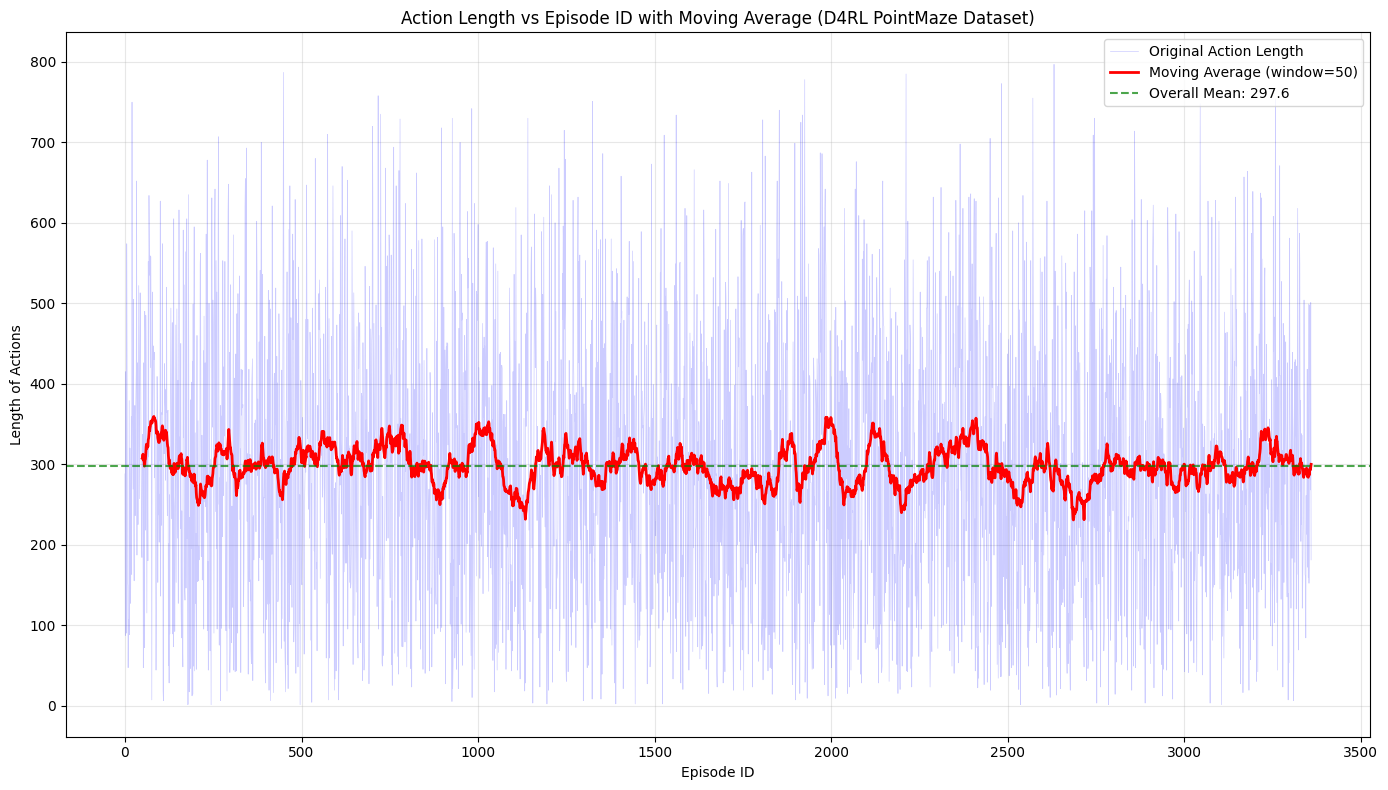


Action Length Statistics:
- Total episodes: 3360
- Min action length: 1
- Max action length: 797
- Mean action length: 297.62
- Moving average window size: 50
- Moving average range: 230.7 - 359.2


In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Collect episode IDs and action lengths
episode_ids = []
action_lengths = []

print("Collecting action lengths for all episodes...")

for i, episode in enumerate(dataset.iterate_episodes()):
    episode_ids.append(i)
    action_lengths.append(len(episode.actions))
    
    # Print progress every 500 episodes
    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{dataset.total_episodes} episodes...")

print(f"Collected data for {len(episode_ids)} episodes")

# Calculate moving average
def moving_average(data, window_size):
    """Calculate moving average with given window size"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Different window sizes for moving averages
window_size = 50  # Adjust this to make it more or less smooth
ma_action_lengths = moving_average(action_lengths, window_size)
ma_episode_ids = episode_ids[window_size-1:]  # Adjust episode IDs for moving average

# Create the plot
plt.figure(figsize=(14, 8))

# Plot original data (more transparent)
plt.plot(episode_ids, action_lengths, 'b-', alpha=0.2, linewidth=0.5, label='Original Action Length')

# Plot moving average (more prominent)
plt.plot(ma_episode_ids, ma_action_lengths, 'r-', linewidth=2, label=f'Moving Average (window={window_size})')

plt.xlabel('Episode ID')
plt.ylabel('Length of Actions')
plt.title(f'Action Length vs Episode ID with Moving Average (D4RL PointMaze Dataset)')
plt.grid(True, alpha=0.3)

# Add statistics
mean_length = sum(action_lengths) / len(action_lengths)
plt.axhline(y=mean_length, color='g', linestyle='--', alpha=0.7, 
           label=f'Overall Mean: {mean_length:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print(f"\nAction Length Statistics:")
print(f"- Total episodes: {len(action_lengths)}")
print(f"- Min action length: {min(action_lengths)}")
print(f"- Max action length: {max(action_lengths)}")
print(f"- Mean action length: {mean_length:.2f}")
print(f"- Moving average window size: {window_size}")
print(f"- Moving average range: {min(ma_action_lengths):.1f} - {max(ma_action_lengths):.1f}")

In [4]:
import gymnasium as gym
import gymnasium_robotics

# Register robotics environments
gym.register_envs(gymnasium_robotics)

# Create PointMaze environment directly
print("Creating PointMaze environment...")
env = gym.make("PointMaze_Large-v3")

print(f"Environment: {env}")
print(f"Environment ID: {env.spec.id}")
print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")

# Reset and explore the environment
print("\n" + "="*50)
print("EXPLORING POINTMAZE ENVIRONMENT")
print("="*50)

# Reset environment
obs, info = env.reset()
print(f"\nInitial reset:")
print(f"- Observation keys: {obs.keys()}")
for key, value in obs.items():
    print(f"  {key}: {value}")
print(f"- Info: {info}")

# Take multiple steps to see the environment behavior
print(f"\nTaking 10 random steps...")
for step in range(10):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    
    print(f"\nStep {step + 1}:")
    print(f"- Action: {action}")
    print(f"- Agent position: {obs['achieved_goal']}")
    print(f"- Goal position: {obs['desired_goal']}")
    print(f"- Reward: {reward}")
    print(f"- Terminated: {terminated}, Truncated: {truncated}")
    print(f"- Success: {info.get('success', 'N/A')}")
    
    if terminated or truncated:
        print("Episode ended!")
        obs, info = env.reset()
        print("Environment reset.")
        break

# Explore environment properties
print(f"\n" + "="*50)
print("ENVIRONMENT PROPERTIES")
print("="*50)

# Check if environment has maze layout or other properties
if hasattr(env, 'maze'):
    print(f"Maze layout: {env.maze}")
if hasattr(env, 'maze_map'):
    print(f"Maze map shape: {env.maze_map.shape}")
if hasattr(env, 'goal_cell'):
    print(f"Goal cell: {env.goal_cell}")

# Check unwrapped environment for more details
unwrapped_env = env.unwrapped
print(f"Unwrapped environment type: {type(unwrapped_env)}")
print(f"Unwrapped environment attributes: {[attr for attr in dir(unwrapped_env) if not attr.startswith('_')]}")

print("\nPointMaze exploration complete!")

Creating PointMaze environment...
Environment: <TimeLimit<OrderEnforcing<PassiveEnvChecker<PointMazeEnv<PointMaze_Large-v3>>>>>
Environment ID: PointMaze_Large-v3
Observation space: Dict('achieved_goal': Box(-inf, inf, (2,), float64), 'desired_goal': Box(-inf, inf, (2,), float64), 'observation': Box(-inf, inf, (4,), float64))
Action space: Box(-1.0, 1.0, (2,), float32)

EXPLORING POINTMAZE ENVIRONMENT

Initial reset:
- Observation keys: dict_keys(['observation', 'achieved_goal', 'desired_goal'])
  observation: [2.6356463 3.1476035 0.        0.       ]
  achieved_goal: [2.6356463 3.1476035]
  desired_goal: [-1.47434408 -3.02958279]
- Info: {'success': False}

Taking 10 random steps...

Step 1:
- Action: [ 0.29922548 -0.36690238]
- Agent position: [2.63635895 3.14672967]
- Goal position: [-1.47434408 -3.02958279]
- Reward: 0.0
- Terminated: False, Truncated: False
- Success: False

Step 2:
- Action: [-0.02256585  0.27265224]
- Agent position: [2.63701615 3.14650729]
- Goal position: [-1.

ADVANCED POINTMAZE ANALYSIS


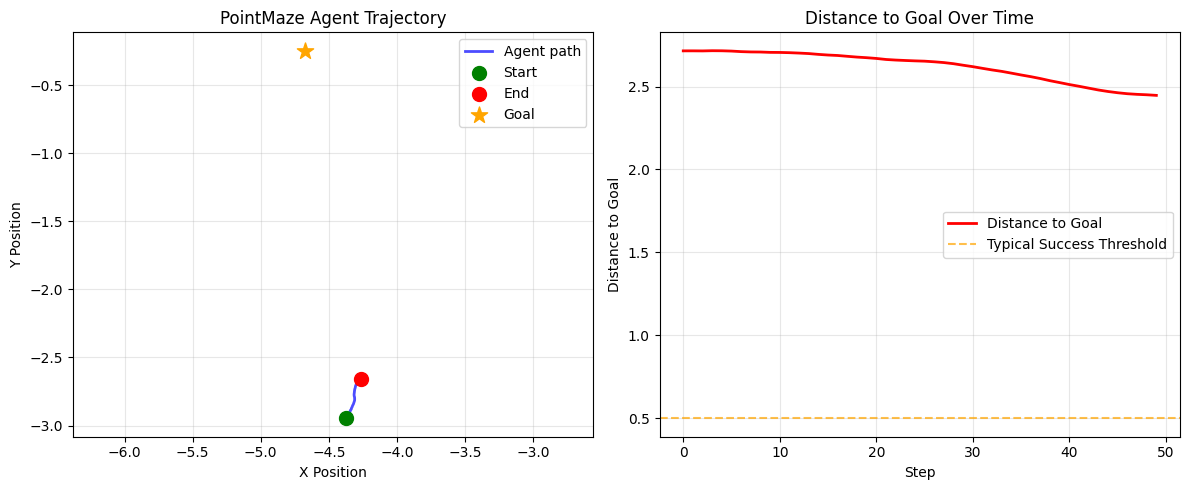


Trajectory Analysis:
- Total steps: 50
- Initial position: [-4.37574122 -2.9469206 ]
- Final position: [-4.26413971 -2.66058788]
- Goal position: [-4.67305473 -0.24822264]
- Initial distance to goal: 2.715
- Final distance to goal: 2.447
- Min distance achieved: 2.447
- Total reward: 0.000
- Average reward per step: 0.000

Environment Bounds Analysis:
- X range: [-4.38, -4.26]
- Y range: [-2.95, -2.66]
- Movement variance X: 0.001
- Movement variance Y: 0.009

This data can be used for RND curiosity analysis!


In [6]:
# Additional PointMaze Analysis and Visualization
import matplotlib.pyplot as plt
import numpy as np

print("ADVANCED POINTMAZE ANALYSIS")
print("="*40)

# Reset environment
env.reset()

# Collect trajectory data
trajectory_positions = []
trajectory_goals = []
trajectory_rewards = []
steps = 50

print(f"Collecting trajectory data for {steps} steps...")

for i in range(steps):
    # Take action (you can change this to different strategies)
    action = env.action_space.sample()  # Random action
    
    obs, reward, terminated, truncated, info = env.step(action)
    
    trajectory_positions.append(obs['achieved_goal'].copy())
    trajectory_goals.append(obs['desired_goal'].copy())
    trajectory_rewards.append(reward)
    
    if terminated or truncated:
        print(f"Episode ended at step {i}")
        break

# Convert to numpy arrays for easier plotting
positions = np.array(trajectory_positions)
goals = np.array(trajectory_goals)
rewards = np.array(trajectory_rewards)

# Create visualization
plt.figure(figsize=(12, 5))

# Plot 1: Agent trajectory
plt.subplot(1, 2, 1)
plt.plot(positions[:, 0], positions[:, 1], 'b-', alpha=0.7, linewidth=2, label='Agent path')
plt.scatter(positions[0, 0], positions[0, 1], color='green', s=100, label='Start', zorder=5)
plt.scatter(positions[-1, 0], positions[-1, 1], color='red', s=100, label='End', zorder=5)
plt.scatter(goals[0, 0], goals[0, 1], color='orange', s=150, marker='*', label='Goal', zorder=5)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('PointMaze Agent Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Distance to goal over time
plt.subplot(1, 2, 2)
distances = np.linalg.norm(positions - goals, axis=1)
plt.plot(distances, 'r-', linewidth=2, label='Distance to Goal')
plt.axhline(y=0.5, color='orange', linestyle='--', alpha=0.7, label='Typical Success Threshold')
plt.xlabel('Step')
plt.ylabel('Distance to Goal')
plt.title('Distance to Goal Over Time')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print analysis
print(f"\nTrajectory Analysis:")
print(f"- Total steps: {len(positions)}")
print(f"- Initial position: {positions[0]}")
print(f"- Final position: {positions[-1]}")
print(f"- Goal position: {goals[0]}")
print(f"- Initial distance to goal: {distances[0]:.3f}")
print(f"- Final distance to goal: {distances[-1]:.3f}")
print(f"- Min distance achieved: {distances.min():.3f}")
print(f"- Total reward: {rewards.sum():.3f}")
print(f"- Average reward per step: {rewards.mean():.3f}")

# Environment bounds analysis
print(f"\nEnvironment Bounds Analysis:")
print(f"- X range: [{positions[:, 0].min():.2f}, {positions[:, 0].max():.2f}]")
print(f"- Y range: [{positions[:, 1].min():.2f}, {positions[:, 1].max():.2f}]")
print(f"- Movement variance X: {positions[:, 0].var():.3f}")
print(f"- Movement variance Y: {positions[:, 1].var():.3f}")

print("\nThis data can be used for RND curiosity analysis!")

In [6]:
# Find the center coordinates (before noise) of goal and reset positions
import numpy as np
import matplotlib.pyplot as plt

print("ANALYZING CENTER COORDINATES (BEFORE NOISE)")
print("="*50)

# Access the unwrapped environment to get maze information
unwrapped_env = env.unwrapped

# Get maze properties
print("Maze Properties:")
maze_map = unwrapped_env.maze.maze_map
print(f"- Maze map dimensions: {len(maze_map)} x {len(maze_map[0]) if maze_map else 0}")
print(f"- Maze size scaling: {unwrapped_env.maze.maze_size_scaling}")
print(f"- Maze type: {type(unwrapped_env.maze)}")

# Get unique goal and reset locations (before noise)
print(f"\nUnique Goal Locations (centers before noise):")
goal_locations = unwrapped_env.maze.unique_goal_locations
for i, goal_loc in enumerate(goal_locations):
    print(f"  Goal {i}: x={goal_loc[0]:.3f}, y={goal_loc[1]:.3f}")

print(f"\nUnique Reset Locations (centers before noise):")
reset_locations = unwrapped_env.maze.unique_reset_locations
for i, reset_loc in enumerate(reset_locations):
    print(f"  Reset {i}: x={reset_loc[0]:.3f}, y={reset_loc[1]:.3f}")

# Show current goal and reset positions (after noise)
print(f"\nCurrent Episode (after noise applied):")
print(f"- Current goal position: x={unwrapped_env.goal[0]:.3f}, y={unwrapped_env.goal[1]:.3f}")
print(f"- Current reset position: x={unwrapped_env.reset_pos[0]:.3f}, y={unwrapped_env.reset_pos[1]:.3f}")

# Show noise range
print(f"\nNoise Configuration:")
print(f"- Position noise range: ±{unwrapped_env.position_noise_range}")
print(f"- Actual noise applied: ±{unwrapped_env.position_noise_range * unwrapped_env.maze.maze_size_scaling}")

# Reset multiple times to see the pattern
print(f"\nMultiple Resets Analysis (showing centers vs noisy positions):")
print("-" * 60)

for reset_num in range(5):
    # Reset environment
    obs, info = env.reset()
    
    # Find which goal location was selected (closest to current goal)
    distances_to_goals = [np.linalg.norm(unwrapped_env.goal - goal_loc) 
                         for goal_loc in goal_locations]
    selected_goal_idx = np.argmin(distances_to_goals)
    selected_goal_center = goal_locations[selected_goal_idx]
    
    # Find which reset location was selected
    distances_to_resets = [np.linalg.norm(unwrapped_env.reset_pos - reset_loc) 
                          for reset_loc in reset_locations]
    selected_reset_idx = np.argmin(distances_to_resets)
    selected_reset_center = reset_locations[selected_reset_idx]
    
    print(f"\nReset {reset_num + 1}:")
    print(f"  Goal - Center: ({selected_goal_center[0]:.3f}, {selected_goal_center[1]:.3f}) → "
          f"Noisy: ({unwrapped_env.goal[0]:.3f}, {unwrapped_env.goal[1]:.3f})")
    print(f"  Reset - Center: ({selected_reset_center[0]:.3f}, {selected_reset_center[1]:.3f}) → "
          f"Noisy: ({unwrapped_env.reset_pos[0]:.3f}, {unwrapped_env.reset_pos[1]:.3f})")
    
    # Calculate actual noise applied
    goal_noise = unwrapped_env.goal - selected_goal_center
    reset_noise = unwrapped_env.reset_pos - selected_reset_center
    print(f"  Applied noise - Goal: ({goal_noise[0]:.3f}, {goal_noise[1]:.3f}), "
          f"Reset: ({reset_noise[0]:.3f}, {reset_noise[1]:.3f})")

print("\nSummary: The 'center' coordinates are the unique_goal_locations and unique_reset_locations!")

ANALYZING CENTER COORDINATES (BEFORE NOISE)
Maze Properties:
- Maze map dimensions: 9 x 12
- Maze size scaling: 1
- Maze type: <class 'gymnasium_robotics.envs.maze.maze_v4.Maze'>

Unique Goal Locations (centers before noise):
  Goal 0: x=-4.500, y=3.000
  Goal 1: x=-3.500, y=3.000
  Goal 2: x=-2.500, y=3.000
  Goal 3: x=-1.500, y=3.000
  Goal 4: x=0.500, y=3.000
  Goal 5: x=1.500, y=3.000
  Goal 6: x=2.500, y=3.000
  Goal 7: x=3.500, y=3.000
  Goal 8: x=4.500, y=3.000
  Goal 9: x=-4.500, y=2.000
  Goal 10: x=-1.500, y=2.000
  Goal 11: x=0.500, y=2.000
  Goal 12: x=2.500, y=2.000
  Goal 13: x=4.500, y=2.000
  Goal 14: x=-4.500, y=1.000
  Goal 15: x=-3.500, y=1.000
  Goal 16: x=-2.500, y=1.000
  Goal 17: x=-1.500, y=1.000
  Goal 18: x=-0.500, y=1.000
  Goal 19: x=0.500, y=1.000
  Goal 20: x=2.500, y=1.000
  Goal 21: x=3.500, y=1.000
  Goal 22: x=4.500, y=1.000
  Goal 23: x=-4.500, y=0.000
  Goal 24: x=0.500, y=0.000
  Goal 25: x=4.500, y=0.000
  Goal 26: x=-4.500, y=-1.000
  Goal 27: x=-

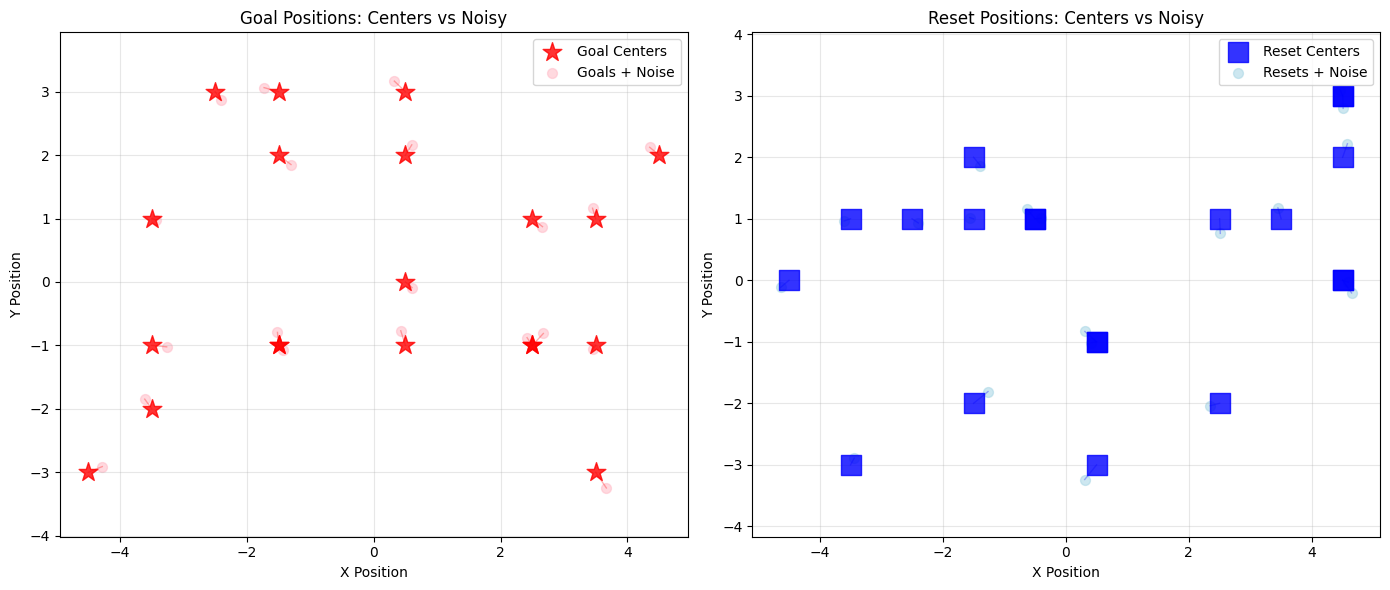


Center Coordinates Summary:
Unique Goal Centers: 18
Unique Reset Centers: 16

All Goal Centers (x, y):
  Goal Center 0: (-4.500, -3.000)
  Goal Center 1: (-3.500, -2.000)
  Goal Center 2: (-3.500, -1.000)
  Goal Center 3: (-3.500, 1.000)
  Goal Center 4: (-2.500, 3.000)
  Goal Center 5: (-1.500, -1.000)
  Goal Center 6: (-1.500, 2.000)
  Goal Center 7: (-1.500, 3.000)
  Goal Center 8: (0.500, -1.000)
  Goal Center 9: (0.500, 0.000)
  Goal Center 10: (0.500, 2.000)
  Goal Center 11: (0.500, 3.000)
  Goal Center 12: (2.500, -1.000)
  Goal Center 13: (2.500, 1.000)
  Goal Center 14: (3.500, -3.000)
  Goal Center 15: (3.500, -1.000)
  Goal Center 16: (3.500, 1.000)
  Goal Center 17: (4.500, 2.000)

All Reset Centers (x, y):
  Reset Center 0: (-4.500, 0.000)
  Reset Center 1: (-3.500, -3.000)
  Reset Center 2: (-3.500, 1.000)
  Reset Center 3: (-2.500, 1.000)
  Reset Center 4: (-1.500, -2.000)
  Reset Center 5: (-1.500, 1.000)
  Reset Center 6: (-1.500, 2.000)
  Reset Center 7: (-0.500, 1.

In [9]:
# Visualize center coordinates vs noisy positions
plt.figure(figsize=(14, 6))

# Collect data for multiple resets
center_goals = []
noisy_goals = []
center_resets = []
noisy_resets = []

print("Collecting data for 20 resets to visualize noise pattern...")

for i in range(20):
    obs, info = env.reset()
    
    # Find selected centers
    distances_to_goals = [np.linalg.norm(unwrapped_env.goal - goal_loc) 
                         for goal_loc in goal_locations]
    selected_goal_center = goal_locations[np.argmin(distances_to_goals)]
    
    distances_to_resets = [np.linalg.norm(unwrapped_env.reset_pos - reset_loc) 
                          for reset_loc in reset_locations]
    selected_reset_center = reset_locations[np.argmin(distances_to_resets)]
    
    center_goals.append(selected_goal_center)
    noisy_goals.append(unwrapped_env.goal.copy())
    center_resets.append(selected_reset_center)
    noisy_resets.append(unwrapped_env.reset_pos.copy())

# Convert to numpy arrays
center_goals = np.array(center_goals)
noisy_goals = np.array(noisy_goals)
center_resets = np.array(center_resets)
noisy_resets = np.array(noisy_resets)

# Plot 1: Goal positions
plt.subplot(1, 2, 1)
plt.scatter(center_goals[:, 0], center_goals[:, 1], 
           c='red', marker='*', s=200, alpha=0.8, label='Goal Centers', zorder=5)
plt.scatter(noisy_goals[:, 0], noisy_goals[:, 1], 
           c='pink', marker='o', s=50, alpha=0.6, label='Goals + Noise')

# Draw lines connecting centers to noisy positions
for i in range(len(center_goals)):
    plt.plot([center_goals[i, 0], noisy_goals[i, 0]], 
            [center_goals[i, 1], noisy_goals[i, 1]], 
            'r-', alpha=0.3, linewidth=1)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Goal Positions: Centers vs Noisy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Reset positions
plt.subplot(1, 2, 2)
plt.scatter(center_resets[:, 0], center_resets[:, 1], 
           c='blue', marker='s', s=200, alpha=0.8, label='Reset Centers', zorder=5)
plt.scatter(noisy_resets[:, 0], noisy_resets[:, 1], 
           c='lightblue', marker='o', s=50, alpha=0.6, label='Resets + Noise')

# Draw lines connecting centers to noisy positions
for i in range(len(center_resets)):
    plt.plot([center_resets[i, 0], noisy_resets[i, 0]], 
            [center_resets[i, 1], noisy_resets[i, 1]], 
            'b-', alpha=0.3, linewidth=1)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Reset Positions: Centers vs Noisy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nCenter Coordinates Summary:")
print(f"Unique Goal Centers: {len(np.unique(center_goals, axis=0))}")
print(f"Unique Reset Centers: {len(np.unique(center_resets, axis=0))}")

unique_goal_centers = np.unique(center_goals, axis=0)
unique_reset_centers = np.unique(center_resets, axis=0)

print(f"\nAll Goal Centers (x, y):")
for i, center in enumerate(unique_goal_centers):
    print(f"  Goal Center {i}: ({center[0]:.3f}, {center[1]:.3f})")

print(f"\nAll Reset Centers (x, y):")
for i, center in enumerate(unique_reset_centers):
    print(f"  Reset Center {i}: ({center[0]:.3f}, {center[1]:.3f})")

print(f"\nNoise Analysis:")
goal_noise_magnitude = np.linalg.norm(noisy_goals - center_goals, axis=1)
reset_noise_magnitude = np.linalg.norm(noisy_resets - center_resets, axis=1)

print(f"Goal noise magnitude - Mean: {goal_noise_magnitude.mean():.3f}, Std: {goal_noise_magnitude.std():.3f}")
print(f"Reset noise magnitude - Mean: {reset_noise_magnitude.mean():.3f}, Std: {reset_noise_magnitude.std():.3f}")
print(f"Max noise range: ±{unwrapped_env.position_noise_range:.3f}")

Processed 500/3360 episodes...
Processed 1000/3360 episodes...
Processed 1500/3360 episodes...
Processed 2000/3360 episodes...
Processed 2500/3360 episodes...
Processed 3000/3360 episodes...
Collected reward data for 3360 episodes


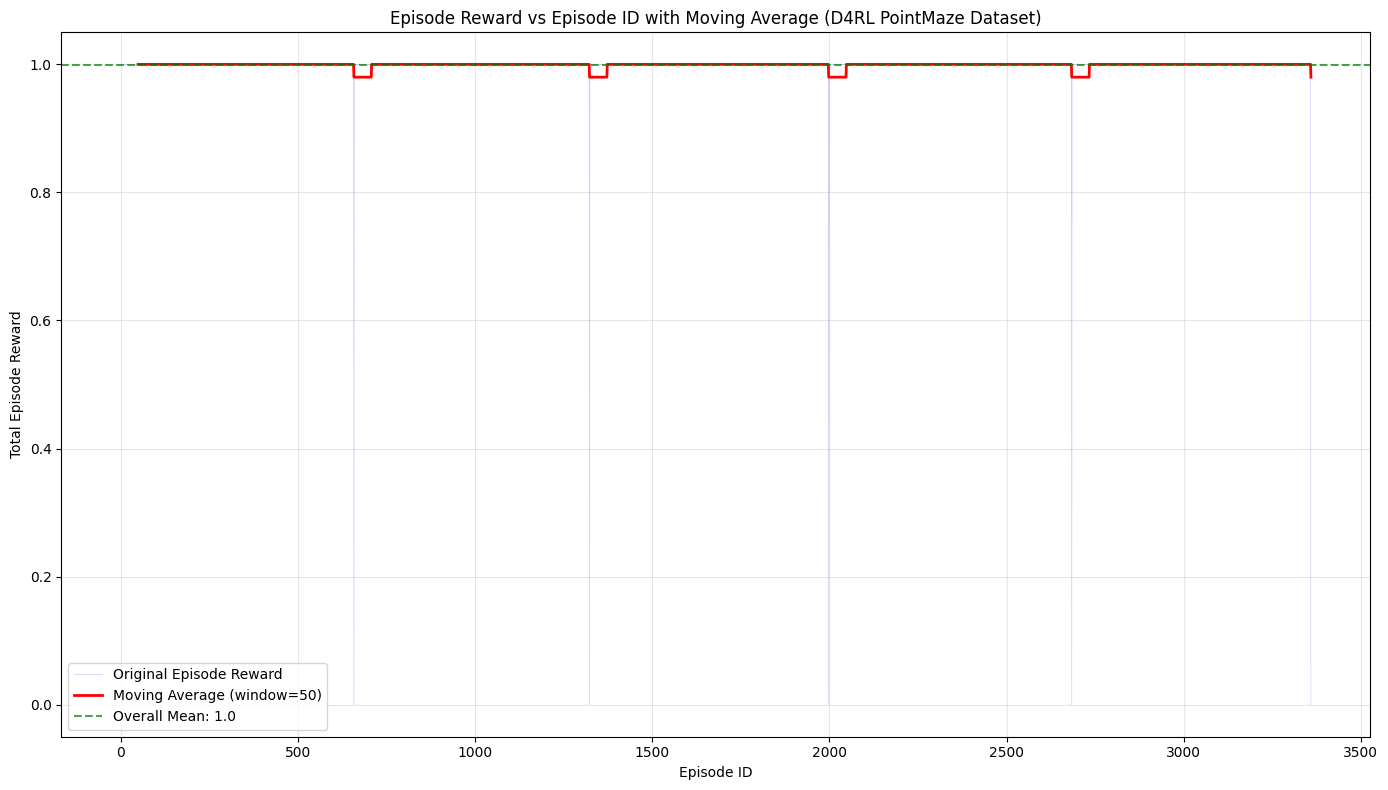


Episode Reward Statistics:
- Total episodes: 3360
- Min episode reward: 0.00
- Max episode reward: 1.00
- Mean episode reward: 1.00
- Std episode reward: 0.04
- Moving average window size: 50
- Moving average range: 1.0 - 1.0

Success Analysis (reward > -5.0):
- Successful episodes: 3360 / 3360 (100.0%)
- Mean reward of successful episodes: 1.00


In [8]:
# Collect episode IDs and total rewards
import matplotlib.pyplot as plt
import numpy as np

episode_ids = []
episode_rewards = []

print("Collecting total rewards for all episodes...")

for i, episode in enumerate(dataset.iterate_episodes()):
    episode_ids.append(i)
    # Sum all rewards in the episode to get total reward
    total_reward = np.sum(episode.rewards)
    episode_rewards.append(total_reward)
    
    # Print progress every 500 episodes
    if (i + 1) % 500 == 0:
        print(f"Processed {i + 1}/{dataset.total_episodes} episodes...")

print(f"Collected reward data for {len(episode_ids)} episodes")

# Calculate moving average
def moving_average(data, window_size):
    """Calculate moving average with given window size"""
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Different window sizes for moving averages
window_size = 50  # Adjust this to make it more or less smooth
ma_episode_rewards = moving_average(episode_rewards, window_size)
ma_episode_ids = episode_ids[window_size-1:]  # Adjust episode IDs for moving average

# Create the plot
plt.figure(figsize=(14, 8))

# Plot original data (more transparent)
plt.plot(episode_ids, episode_rewards, 'b-', alpha=0.2, linewidth=0.5, label='Original Episode Reward')

# Plot moving average (more prominent)
plt.plot(ma_episode_ids, ma_episode_rewards, 'r-', linewidth=2, label=f'Moving Average (window={window_size})')

plt.xlabel('Episode ID')
plt.ylabel('Total Episode Reward')
plt.title(f'Episode Reward vs Episode ID with Moving Average (D4RL PointMaze Dataset)')
plt.grid(True, alpha=0.3)

# Add statistics
mean_reward = sum(episode_rewards) / len(episode_rewards)
plt.axhline(y=mean_reward, color='g', linestyle='--', alpha=0.7, 
           label=f'Overall Mean: {mean_reward:.1f}')

plt.legend()
plt.tight_layout()
plt.show()

# Print summary
print(f"\nEpisode Reward Statistics:")
print(f"- Total episodes: {len(episode_rewards)}")
print(f"- Min episode reward: {min(episode_rewards):.2f}")
print(f"- Max episode reward: {max(episode_rewards):.2f}")
print(f"- Mean episode reward: {mean_reward:.2f}")
print(f"- Std episode reward: {np.std(episode_rewards):.2f}")
print(f"- Moving average window size: {window_size}")
print(f"- Moving average range: {min(ma_episode_rewards):.1f} - {max(ma_episode_rewards):.1f}")

# Additional analysis
success_threshold = -5.0  # Typical success threshold for sparse reward environments
successful_episodes = [r for r in episode_rewards if r > success_threshold]
print(f"\nSuccess Analysis (reward > {success_threshold}):")
print(f"- Successful episodes: {len(successful_episodes)} / {len(episode_rewards)} ({100*len(successful_episodes)/len(episode_rewards):.1f}%)")
if successful_episodes:
    print(f"- Mean reward of successful episodes: {np.mean(successful_episodes):.2f}")

DETAILED REWARD ANALYSIS
Episode Reward Distribution:
- Total episodes analyzed: 3360
- Minimum reward: 0.000000
- Maximum reward: 1.000000
- Mean reward: 0.998512
- Median reward: 1.000000
- Standard deviation: 0.038547

Unique reward values found: 2
First 10 unique rewards: [0. 1.]

Reward value frequency (top 10):
  Reward 1.000000: 3355 episodes (99.9%)
  Reward 0.000000: 5 episodes (0.1%)

Episodes with zero rewards: 5
Zero reward episode indices (first 10): [658, 1323, 1998, 2684, 3359]
Episodes with negative rewards: 0

INDIVIDUAL EPISODE REWARD STRUCTURE ANALYSIS

Episode 0:
  Total episode reward: 1.000000
  Episode length: 288 steps
  Individual step rewards (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Individual step rewards (last 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
  Unique step reward values: [0. 1.]
  Sum verification: 1.000000

Episode 100:
  Total episode reward: 1.000000
  Episode length: 627 steps
  Individual step rewards (first 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

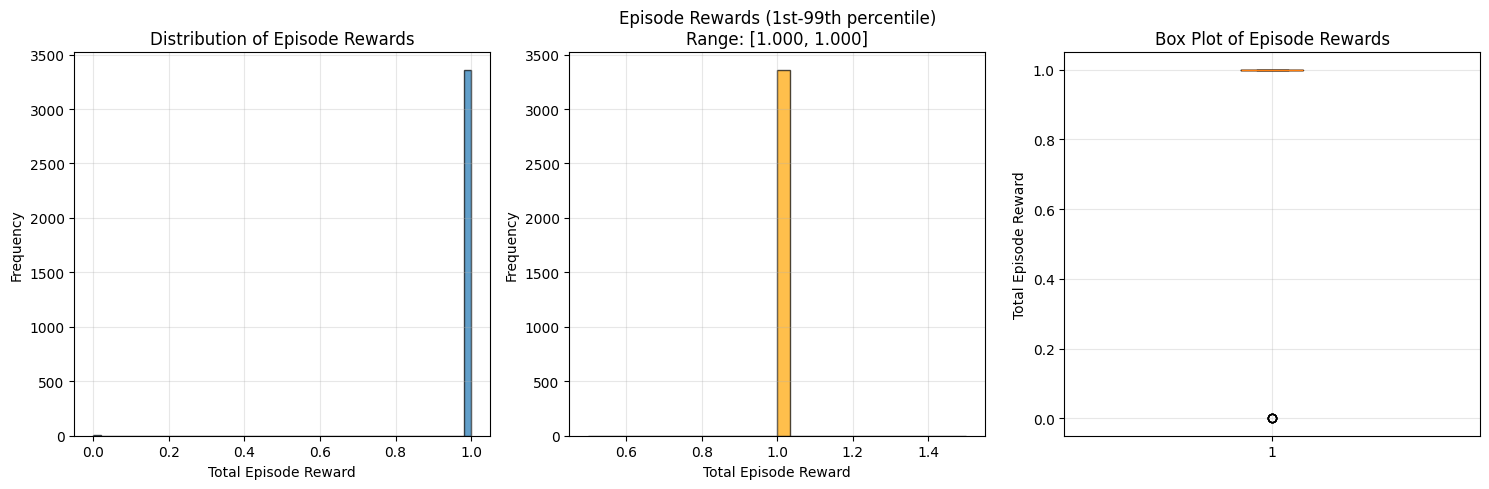


Environment Maximum Reward Analysis:
The maximum observed episode reward in this dataset is: 1.000000
This suggests the theoretical maximum reward per episode is around 1


In [9]:
# Detailed Reward Analysis
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("DETAILED REWARD ANALYSIS")
print("="*50)

# Basic statistics
print(f"Episode Reward Distribution:")
print(f"- Total episodes analyzed: {len(episode_rewards)}")
print(f"- Minimum reward: {min(episode_rewards):.6f}")
print(f"- Maximum reward: {max(episode_rewards):.6f}")
print(f"- Mean reward: {np.mean(episode_rewards):.6f}")
print(f"- Median reward: {np.median(episode_rewards):.6f}")
print(f"- Standard deviation: {np.std(episode_rewards):.6f}")

# Check for unique reward values
unique_rewards = np.unique(episode_rewards)
print(f"\nUnique reward values found: {len(unique_rewards)}")
print("First 10 unique rewards:", unique_rewards[:10])
if len(unique_rewards) > 10:
    print("Last 10 unique rewards:", unique_rewards[-10:])

# Count episodes with specific reward values
reward_counts = Counter(episode_rewards)
print(f"\nReward value frequency (top 10):")
for reward, count in reward_counts.most_common(10):
    percentage = (count / len(episode_rewards)) * 100
    print(f"  Reward {reward:.6f}: {count} episodes ({percentage:.1f}%)")

# Check for zero rewards
zero_reward_episodes = [i for i, r in enumerate(episode_rewards) if abs(r) < 1e-10]
print(f"\nEpisodes with zero rewards: {len(zero_reward_episodes)}")
if zero_reward_episodes:
    print(f"Zero reward episode indices (first 10): {zero_reward_episodes[:10]}")

# Check for negative rewards
negative_reward_episodes = [r for r in episode_rewards if r < 0]
print(f"Episodes with negative rewards: {len(negative_reward_episodes)}")
if negative_reward_episodes:
    print(f"Range of negative rewards: {min(negative_reward_episodes):.6f} to {max(negative_reward_episodes):.6f}")

# Analyze reward structure by looking at individual episodes
print(f"\n" + "="*50)
print("INDIVIDUAL EPISODE REWARD STRUCTURE ANALYSIS")
print("="*50)

# Look at a few episodes to understand the reward structure
sample_episodes = [0, 100, 500, 1000, 2000]  # Sample different episodes
for ep_idx in sample_episodes:
    if ep_idx < len(episode_rewards):
        # Get the actual episode data
        episode_data = list(dataset.iterate_episodes([ep_idx]))[0]
        
        print(f"\nEpisode {ep_idx}:")
        print(f"  Total episode reward: {episode_rewards[ep_idx]:.6f}")
        print(f"  Episode length: {len(episode_data.rewards)} steps")
        print(f"  Individual step rewards (first 10): {episode_data.rewards[:10]}")
        print(f"  Individual step rewards (last 10): {episode_data.rewards[-10:]}")
        print(f"  Unique step reward values: {np.unique(episode_data.rewards)}")
        print(f"  Sum verification: {np.sum(episode_data.rewards):.6f}")

# Create histogram of reward distribution
plt.figure(figsize=(15, 5))

# Plot 1: Histogram of all episode rewards
plt.subplot(1, 3, 1)
plt.hist(episode_rewards, bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Total Episode Reward')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Rewards')
plt.grid(True, alpha=0.3)

# Plot 2: Zoomed in histogram (if there are outliers)
plt.subplot(1, 3, 2)
# Remove extreme outliers for better visualization
q1, q99 = np.percentile(episode_rewards, [1, 99])
filtered_rewards = [r for r in episode_rewards if q1 <= r <= q99]
plt.hist(filtered_rewards, bins=30, alpha=0.7, edgecolor='black', color='orange')
plt.xlabel('Total Episode Reward')
plt.ylabel('Frequency')
plt.title(f'Episode Rewards (1st-99th percentile)\nRange: [{q1:.3f}, {q99:.3f}]')
plt.grid(True, alpha=0.3)

# Plot 3: Box plot
plt.subplot(1, 3, 3)
plt.boxplot(episode_rewards, vert=True)
plt.ylabel('Total Episode Reward')
plt.title('Box Plot of Episode Rewards')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nEnvironment Maximum Reward Analysis:")
print(f"The maximum observed episode reward in this dataset is: {max(episode_rewards):.6f}")
print(f"This suggests the theoretical maximum reward per episode is around {max(episode_rewards):.0f}")

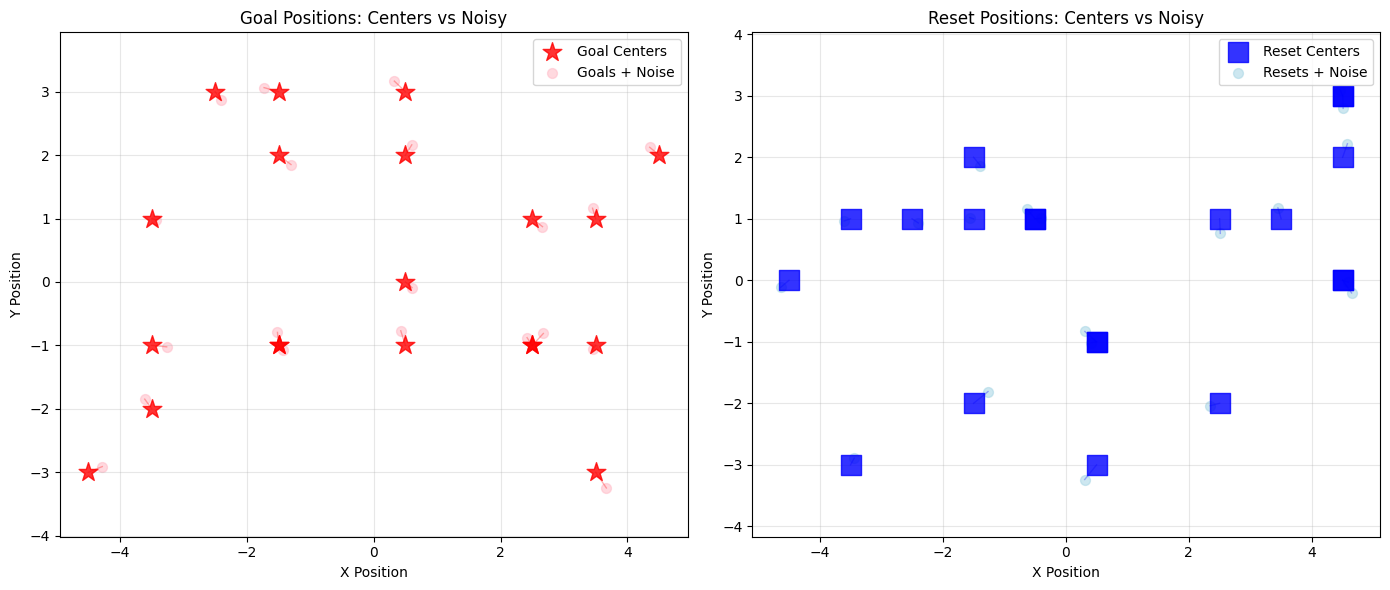


Center Coordinates Summary:
Unique Goal Centers: 18
Unique Reset Centers: 16

All Goal Centers (x, y):
  Goal Center 0: (-4.500, -3.000)
  Goal Center 1: (-3.500, -2.000)
  Goal Center 2: (-3.500, -1.000)
  Goal Center 3: (-3.500, 1.000)
  Goal Center 4: (-2.500, 3.000)
  Goal Center 5: (-1.500, -1.000)
  Goal Center 6: (-1.500, 2.000)
  Goal Center 7: (-1.500, 3.000)
  Goal Center 8: (0.500, -1.000)
  Goal Center 9: (0.500, 0.000)
  Goal Center 10: (0.500, 2.000)
  Goal Center 11: (0.500, 3.000)
  Goal Center 12: (2.500, -1.000)
  Goal Center 13: (2.500, 1.000)
  Goal Center 14: (3.500, -3.000)
  Goal Center 15: (3.500, -1.000)
  Goal Center 16: (3.500, 1.000)
  Goal Center 17: (4.500, 2.000)

All Reset Centers (x, y):
  Reset Center 0: (-4.500, 0.000)
  Reset Center 1: (-3.500, -3.000)
  Reset Center 2: (-3.500, 1.000)
  Reset Center 3: (-2.500, 1.000)
  Reset Center 4: (-1.500, -2.000)
  Reset Center 5: (-1.500, 1.000)
  Reset Center 6: (-1.500, 2.000)
  Reset Center 7: (-0.500, 1.

In [ ]:
# Visualize center coordinates vs noisy positions
plt.figure(figsize=(14, 6))

# Collect data for multiple resets
center_goals = []
noisy_goals = []
center_resets = []
noisy_resets = []

print("Collecting data for 20 resets to visualize noise pattern...")

for i in range(20):
    obs, info = env.reset()
    
    # Find selected centers
    distances_to_goals = [np.linalg.norm(unwrapped_env.goal - goal_loc) 
                         for goal_loc in goal_locations]
    selected_goal_center = goal_locations[np.argmin(distances_to_goals)]
    
    distances_to_resets = [np.linalg.norm(unwrapped_env.reset_pos - reset_loc) 
                          for reset_loc in reset_locations]
    selected_reset_center = reset_locations[np.argmin(distances_to_resets)]
    
    center_goals.append(selected_goal_center)
    noisy_goals.append(unwrapped_env.goal.copy())
    center_resets.append(selected_reset_center)
    noisy_resets.append(unwrapped_env.reset_pos.copy())

# Convert to numpy arrays
center_goals = np.array(center_goals)
noisy_goals = np.array(noisy_goals)
center_resets = np.array(center_resets)
noisy_resets = np.array(noisy_resets)

# Plot 1: Goal positions
plt.subplot(1, 2, 1)
plt.scatter(center_goals[:, 0], center_goals[:, 1], 
           c='red', marker='*', s=200, alpha=0.8, label='Goal Centers', zorder=5)
plt.scatter(noisy_goals[:, 0], noisy_goals[:, 1], 
           c='pink', marker='o', s=50, alpha=0.6, label='Goals + Noise')

# Draw lines connecting centers to noisy positions
for i in range(len(center_goals)):
    plt.plot([center_goals[i, 0], noisy_goals[i, 0]], 
            [center_goals[i, 1], noisy_goals[i, 1]], 
            'r-', alpha=0.3, linewidth=1)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Goal Positions: Centers vs Noisy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot 2: Reset positions
plt.subplot(1, 2, 2)
plt.scatter(center_resets[:, 0], center_resets[:, 1], 
           c='blue', marker='s', s=200, alpha=0.8, label='Reset Centers', zorder=5)
plt.scatter(noisy_resets[:, 0], noisy_resets[:, 1], 
           c='lightblue', marker='o', s=50, alpha=0.6, label='Resets + Noise')

# Draw lines connecting centers to noisy positions
for i in range(len(center_resets)):
    plt.plot([center_resets[i, 0], noisy_resets[i, 0]], 
            [center_resets[i, 1], noisy_resets[i, 1]], 
            'b-', alpha=0.3, linewidth=1)

plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.title('Reset Positions: Centers vs Noisy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nCenter Coordinates Summary:")
print(f"Unique Goal Centers: {len(np.unique(center_goals, axis=0))}")
print(f"Unique Reset Centers: {len(np.unique(center_resets, axis=0))}")

unique_goal_centers = np.unique(center_goals, axis=0)
unique_reset_centers = np.unique(center_resets, axis=0)

print(f"\nAll Goal Centers (x, y):")
for i, center in enumerate(unique_goal_centers):
    print(f"  Goal Center {i}: ({center[0]:.3f}, {center[1]:.3f})")

print(f"\nAll Reset Centers (x, y):")
for i, center in enumerate(unique_reset_centers):
    print(f"  Reset Center {i}: ({center[0]:.3f}, {center[1]:.3f})")

print(f"\nNoise Analysis:")
goal_noise_magnitude = np.linalg.norm(noisy_goals - center_goals, axis=1)
reset_noise_magnitude = np.linalg.norm(noisy_resets - center_resets, axis=1)

print(f"Goal noise magnitude - Mean: {goal_noise_magnitude.mean():.3f}, Std: {goal_noise_magnitude.std():.3f}")
print(f"Reset noise magnitude - Mean: {reset_noise_magnitude.mean():.3f}, Std: {reset_noise_magnitude.std():.3f}")
print(f"Max noise range: ±{unwrapped_env.position_noise_range:.3f}")

EPISODE TERMINATION AND LENGTH ANALYSIS
Based on PointMaze Documentation:
- Episode termination occurs in 2 ways:
  1. TERMINATED: When goal is reached (Euclidean distance ≤ 0.5m)
  2. TRUNCATED: When max_episode_steps is reached
- Default max_episode_steps varies by maze size
- Control frequency: 10 Hz

Analyzing episode lengths from dataset...
Processed 500/3360 episodes...
Processed 1000/3360 episodes...
Processed 1500/3360 episodes...
Processed 2000/3360 episodes...
Processed 2500/3360 episodes...
Processed 3000/3360 episodes...

Episode Length Statistics:
- Total episodes: 3360
- Min episode length: 1 steps
- Max episode length: 797 steps
- Mean episode length: 297.62 steps
- Median episode length: 290.00 steps
- Std episode length: 166.04 steps

Success vs Failure Analysis:
- Successful episodes (reward=1): 3355
  - Mean length: 297.90 steps
  - Max length: 797 steps
  - Min length: 1 steps
- Failed episodes (reward=0): 5
  - Mean length: 106.80 steps
  - Lengths: [119, 8, 75, 15

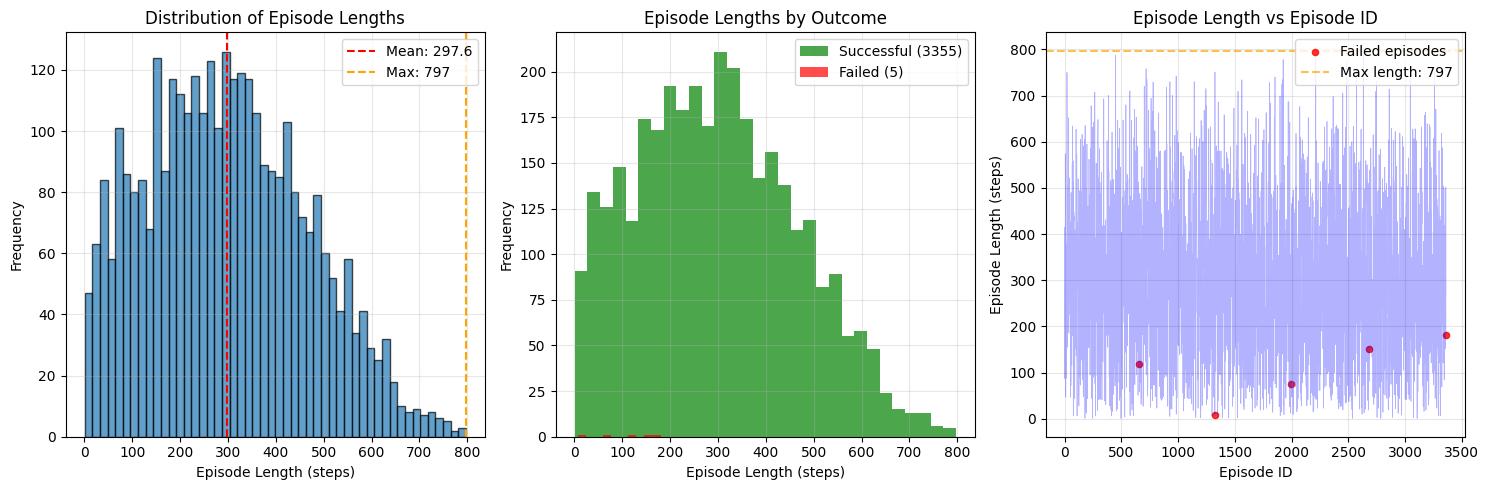


Conclusion:
- The environment appears to have max_episode_steps = 797
- Episodes reaching this limit are truncated
- 3355 episodes terminated successfully (goal reached)
- 5 episodes were likely truncated without reaching the goal


In [10]:
# Episode Termination and Length Analysis
import numpy as np
import matplotlib.pyplot as plt

print("EPISODE TERMINATION AND LENGTH ANALYSIS")
print("="*60)

print("Based on PointMaze Documentation:")
print("- Episode termination occurs in 2 ways:")
print("  1. TERMINATED: When goal is reached (Euclidean distance ≤ 0.5m)")
print("  2. TRUNCATED: When max_episode_steps is reached")
print("- Default max_episode_steps varies by maze size")
print("- Control frequency: 10 Hz")
print()

# Analyze episode lengths from our dataset
episode_lengths = []
episode_termination_info = []

print("Analyzing episode lengths from dataset...")

# Get episode length data (we already have some from action lengths)
if 'action_lengths' in globals():
    episode_lengths = action_lengths.copy()
    print("Using previously collected action_lengths as episode_lengths")
else:
    print("Collecting episode lengths...")
    for i, episode in enumerate(dataset.iterate_episodes()):
        episode_lengths.append(len(episode.actions))
        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1}/{dataset.total_episodes} episodes...")

print(f"\nEpisode Length Statistics:")
print(f"- Total episodes: {len(episode_lengths)}")
print(f"- Min episode length: {min(episode_lengths)} steps")
print(f"- Max episode length: {max(episode_lengths)} steps")
print(f"- Mean episode length: {np.mean(episode_lengths):.2f} steps")
print(f"- Median episode length: {np.median(episode_lengths):.2f} steps")
print(f"- Std episode length: {np.std(episode_lengths):.2f} steps")

# Analyze correlation between episode length and success
successful_episodes_indices = [i for i, r in enumerate(episode_rewards) if r > 0]
failed_episodes_indices = [i for i, r in enumerate(episode_rewards) if r == 0]

successful_lengths = [episode_lengths[i] for i in successful_episodes_indices]
failed_lengths = [episode_lengths[i] for i in failed_episodes_indices]

print(f"\nSuccess vs Failure Analysis:")
print(f"- Successful episodes (reward=1): {len(successful_lengths)}")
print(f"  - Mean length: {np.mean(successful_lengths):.2f} steps")
print(f"  - Max length: {max(successful_lengths)} steps")
print(f"  - Min length: {min(successful_lengths)} steps")

if failed_lengths:
    print(f"- Failed episodes (reward=0): {len(failed_lengths)}")
    print(f"  - Mean length: {np.mean(failed_lengths):.2f} steps")
    print(f"  - Lengths: {failed_lengths}")

# Check if there's a maximum episode length (truncation limit)
max_length = max(episode_lengths)
episodes_at_max = [i for i, length in enumerate(episode_lengths) if length == max_length]

print(f"\nTruncation Analysis:")
print(f"- Maximum episode length observed: {max_length} steps")
print(f"- Episodes at maximum length: {len(episodes_at_max)}")
if len(episodes_at_max) > 0:
    print(f"- Episode indices at max length: {episodes_at_max[:10]}...")  # Show first 10
    # Check if these are successful or failed episodes
    max_length_rewards = [episode_rewards[i] for i in episodes_at_max]
    print(f"- Rewards for max-length episodes: {set(max_length_rewards)}")

# Time analysis (assuming 10 Hz control frequency)
control_freq = 10  # Hz
mean_time_seconds = np.mean(episode_lengths) / control_freq
max_time_seconds = max_length / control_freq

print(f"\nTime Analysis (at 10 Hz control frequency):")
print(f"- Mean episode duration: {mean_time_seconds:.2f} seconds")
print(f"- Maximum episode duration: {max_time_seconds:.2f} seconds")

# Plot episode length distribution
plt.figure(figsize=(15, 5))

# Plot 1: Histogram of episode lengths
plt.subplot(1, 3, 1)
plt.hist(episode_lengths, bins=50, alpha=0.7, edgecolor='black')
plt.axvline(np.mean(episode_lengths), color='red', linestyle='--', 
           label=f'Mean: {np.mean(episode_lengths):.1f}')
plt.axvline(max_length, color='orange', linestyle='--', 
           label=f'Max: {max_length}')
plt.xlabel('Episode Length (steps)')
plt.ylabel('Frequency')
plt.title('Distribution of Episode Lengths')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Success vs Failed episode lengths
plt.subplot(1, 3, 2)
if successful_lengths:
    plt.hist(successful_lengths, bins=30, alpha=0.7, 
             label=f'Successful ({len(successful_lengths)})', color='green')
if failed_lengths:
    plt.hist(failed_lengths, bins=10, alpha=0.7, 
             label=f'Failed ({len(failed_lengths)})', color='red')
plt.xlabel('Episode Length (steps)')
plt.ylabel('Frequency')
plt.title('Episode Lengths by Outcome')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Episode length vs Episode ID
plt.subplot(1, 3, 3)
plt.plot(range(len(episode_lengths)), episode_lengths, 'b-', alpha=0.3, linewidth=0.5)
# Highlight failed episodes
if failed_episodes_indices:
    failed_lengths_plot = [episode_lengths[i] for i in failed_episodes_indices]
    plt.scatter(failed_episodes_indices, failed_lengths_plot, 
               color='red', s=20, alpha=0.8, label='Failed episodes')
plt.axhline(max_length, color='orange', linestyle='--', alpha=0.7,
           label=f'Max length: {max_length}')
plt.xlabel('Episode ID')
plt.ylabel('Episode Length (steps)')
plt.title('Episode Length vs Episode ID')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nConclusion:")
if len(episodes_at_max) > 0:
    print(f"- The environment appears to have max_episode_steps = {max_length}")
    print(f"- Episodes reaching this limit are truncated")
else:
    print(f"- No episodes reached a consistent maximum length")
    print(f"- Most episodes terminate when the goal is reached")

print(f"- {len(successful_lengths)} episodes terminated successfully (goal reached)")
print(f"- {len(failed_lengths)} episodes were likely truncated without reaching the goal")

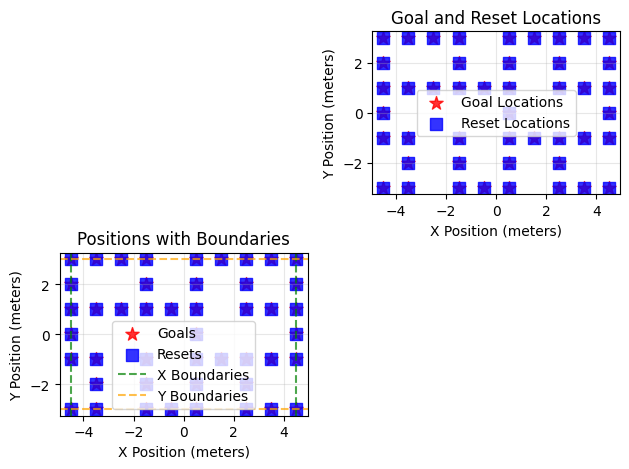


SUMMARY:
Environment: PointMaze_Large-v3
Maze size: 9x12 cells, 1m per cell
Physical boundaries:
  X: [-4.75, 4.75] meters
  Y: [-3.25, 3.25] meters

Dimensions:
  Width: 9.50 meters
  Height: 6.50 meters

VERSION COMPATIBILITY:
- Dataset: D4RL/pointmaze/large-v2 (Minari format)
- Environment: PointMaze_Large-v3 (Gymnasium)
- Both use the SAME maze layout: 9x12 cells
- Both have the SAME boundaries: ~9.5m x 6.5m
- Version difference is just the API format, NOT the maze itself


In [13]:
# Plot goal and reset locations
plt.subplot(2, 2, 2)
goal_locations_array = np.array(goal_locations)
reset_locations_array = np.array(reset_locations)
goal_x, goal_y = goal_locations_array[:, 0], goal_locations_array[:, 1]
reset_x, reset_y = reset_locations_array[:, 0], reset_locations_array[:, 1]

plt.scatter(goal_x, goal_y, c='red', marker='*', s=100, alpha=0.8, label='Goal Locations')
plt.scatter(reset_x, reset_y, c='blue', marker='s', s=80, alpha=0.8, label='Reset Locations')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.title('Goal and Reset Locations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Plot with boundaries
plt.subplot(2, 2, 3)
plt.scatter(goal_x, goal_y, c='red', marker='*', s=100, alpha=0.8, label='Goals')
plt.scatter(reset_x, reset_y, c='blue', marker='s', s=80, alpha=0.8, label='Resets')

# Add boundary lines
plt.axvline(actual_x_min, color='green', linestyle='--', alpha=0.7, label='X Boundaries')
plt.axvline(actual_x_max, color='green', linestyle='--', alpha=0.7)
plt.axhline(actual_y_min, color='orange', linestyle='--', alpha=0.7, label='Y Boundaries')
plt.axhline(actual_y_max, color='orange', linestyle='--', alpha=0.7)

plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.title('Positions with Boundaries')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Show dataset positions if available
if dataset_positions:
    plt.subplot(2, 2, 4)
    plt.scatter(dataset_positions[:, 0], dataset_positions[:, 1], 
               c='purple', alpha=0.1, s=1, label='Agent Positions (Sample)')
    plt.xlabel('X Position (meters)')
    plt.ylabel('Y Position (meters)')
    plt.title('Sample Agent Positions\n(First Few Episodes)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nSUMMARY:")
print(f"Environment: PointMaze_Large-v3")
print(f"Maze size: {rows}x{cols} cells, {cell_size}m per cell")
print(f"Physical boundaries:")
print(f"  X: [{actual_x_min-noise_range:.2f}, {actual_x_max+noise_range:.2f}] meters")
print(f"  Y: [{actual_y_min-noise_range:.2f}, {actual_y_max+noise_range:.2f}] meters")
print(f"\nDimensions:")
print(f"  Width: {(actual_x_max-actual_x_min+2*noise_range):.2f} meters")  
print(f"  Height: {(actual_y_max-actual_y_min+2*noise_range):.2f} meters")
print(f"\nVERSION COMPATIBILITY:")
print(f"- Dataset: D4RL/pointmaze/large-v2 (Minari format)")
print(f"- Environment: PointMaze_Large-v3 (Gymnasium)")
print(f"- Both use the SAME maze layout: 9x12 cells")
print(f"- Both have the SAME boundaries: ~9.5m x 6.5m")
print(f"- Version difference is just the API format, NOT the maze itself")

In [14]:
# DETAILED BOUNDARY ANALYSIS: Why boundaries ≠ grid dimensions
print("\n" + "="*60)
print("WHY BOUNDARIES DON'T MATCH GRID DIMENSIONS")
print("="*60)

print("THEORETICAL vs ACTUAL boundaries:")
print(f"- Grid dimensions: {rows}×{cols} = {rows}×{cols} cells")
print(f"- Cell size: {cell_size}m per cell")
print(f"- Theoretical full maze: {rows}×{cell_size}m × {cols}×{cell_size}m = {rows*cell_size}×{cols*cell_size}m")

# Calculate theoretical boundaries if we used the full grid
theoretical_x_range = cols * cell_size  # 12m
theoretical_y_range = rows * cell_size  # 9m
theoretical_x_center = theoretical_x_range / 2  # 6m
theoretical_y_center = theoretical_y_range / 2  # 4.5m

print(f"- Theoretical range: X[0, {theoretical_x_range}] × Y[0, {theoretical_y_range}]")
print(f"- If centered at origin: X[{-theoretical_x_center}, {theoretical_x_center}] × Y[{-theoretical_y_center}, {theoretical_y_center}]")

print(f"\nACTUAL boundaries (from goal/reset positions):")
print(f"- X: [{actual_x_min:.1f}, {actual_x_max:.1f}] = {actual_x_max-actual_x_min:.1f}m wide")
print(f"- Y: [{actual_y_min:.1f}, {actual_y_max:.1f}] = {actual_y_max-actual_y_min:.1f}m tall")

print(f"\nWhy the difference?")
print(f"1. WALLS: Not all grid cells are accessible")
print(f"2. PLACEMENT RULES: Goals/resets only placed in FREE SPACE")
print(f"3. MAZE DESIGN: The maze doesn't use the full grid")

# Analyze which cells are free vs walls
print(f"\nMAZE CELL ANALYSIS:")
free_cells = []
wall_cells = []

for i in range(rows):
    for j in range(cols):
        if maze_map[i][j] == 0:  # Free space
            # Convert grid coordinates to world coordinates
            # Grid (0,0) is bottom-left, world coordinates centered at origin
            world_x = j - (cols-1)/2  # j ranges 0-11, centered gives -5.5 to +5.5
            world_y = i - (rows-1)/2  # i ranges 0-8, centered gives -4 to +4
            free_cells.append((world_x, world_y, i, j))
        else:  # Wall
            wall_cells.append((i, j))

print(f"- Total cells: {rows * cols}")
print(f"- Free cells: {len(free_cells)}")
print(f"- Wall cells: {len(wall_cells)}")
print(f"- Free space percentage: {100*len(free_cells)/(rows*cols):.1f}%")

# Find the actual range of free cells
free_cells_array = np.array(free_cells)
free_x_min, free_x_max = free_cells_array[:, 0].min(), free_cells_array[:, 0].max()
free_y_min, free_y_max = free_cells_array[:, 1].min(), free_cells_array[:, 1].max()

print(f"\nFREE CELL boundaries:")
print(f"- X: [{free_x_min:.1f}, {free_x_max:.1f}] = {free_x_max-free_x_min:.1f}m wide")
print(f"- Y: [{free_y_min:.1f}, {free_y_max:.1f}] = {free_y_max-free_y_min:.1f}m tall")

print(f"\nGOAL/RESET vs FREE CELL comparison:")
print(f"- Goal/Reset X range: [{actual_x_min:.1f}, {actual_x_max:.1f}]")
print(f"- Free cells X range: [{free_x_min:.1f}, {free_x_max:.1f}]")
print(f"- Goal/Reset Y range: [{actual_y_min:.1f}, {actual_y_max:.1f}]")
print(f"- Free cells Y range: [{free_y_min:.1f}, {free_y_max:.1f}]")

# Check if goals are placed exactly at cell centers or offset
print(f"\nGOAL PLACEMENT ANALYSIS:")
print("First 10 goal locations vs nearest cell centers:")
for i in range(min(10, len(goal_locations_array))):
    goal_pos = goal_locations_array[i]
    # Find nearest cell center
    nearest_cell_x = round(goal_pos[0])
    nearest_cell_y = round(goal_pos[1])
    offset_x = goal_pos[0] - nearest_cell_x
    offset_y = goal_pos[1] - nearest_cell_y
    print(f"  Goal {i}: ({goal_pos[0]:.1f}, {goal_pos[1]:.1f}) → cell ({nearest_cell_x}, {nearest_cell_y}) offset ({offset_x:.1f}, {offset_y:.1f})")


WHY BOUNDARIES DON'T MATCH GRID DIMENSIONS
THEORETICAL vs ACTUAL boundaries:
- Grid dimensions: 9×12 = 9×12 cells
- Cell size: 1m per cell
- Theoretical full maze: 9×1m × 12×1m = 9×12m
- Theoretical range: X[0, 12] × Y[0, 9]
- If centered at origin: X[-6.0, 6.0] × Y[-4.5, 4.5]

ACTUAL boundaries (from goal/reset positions):
- X: [-4.5, 4.5] = 9.0m wide
- Y: [-3.0, 3.0] = 6.0m tall

Why the difference?
1. WALLS: Not all grid cells are accessible
2. PLACEMENT RULES: Goals/resets only placed in FREE SPACE
3. MAZE DESIGN: The maze doesn't use the full grid

MAZE CELL ANALYSIS:
- Total cells: 108
- Free cells: 46
- Wall cells: 62
- Free space percentage: 42.6%

FREE CELL boundaries:
- X: [-4.5, 4.5] = 9.0m wide
- Y: [-3.0, 3.0] = 6.0m tall

GOAL/RESET vs FREE CELL comparison:
- Goal/Reset X range: [-4.5, 4.5]
- Free cells X range: [-4.5, 4.5]
- Goal/Reset Y range: [-3.0, 3.0]
- Free cells Y range: [-3.0, 3.0]

GOAL PLACEMENT ANALYSIS:
First 10 goal locations vs nearest cell centers:
  Goal

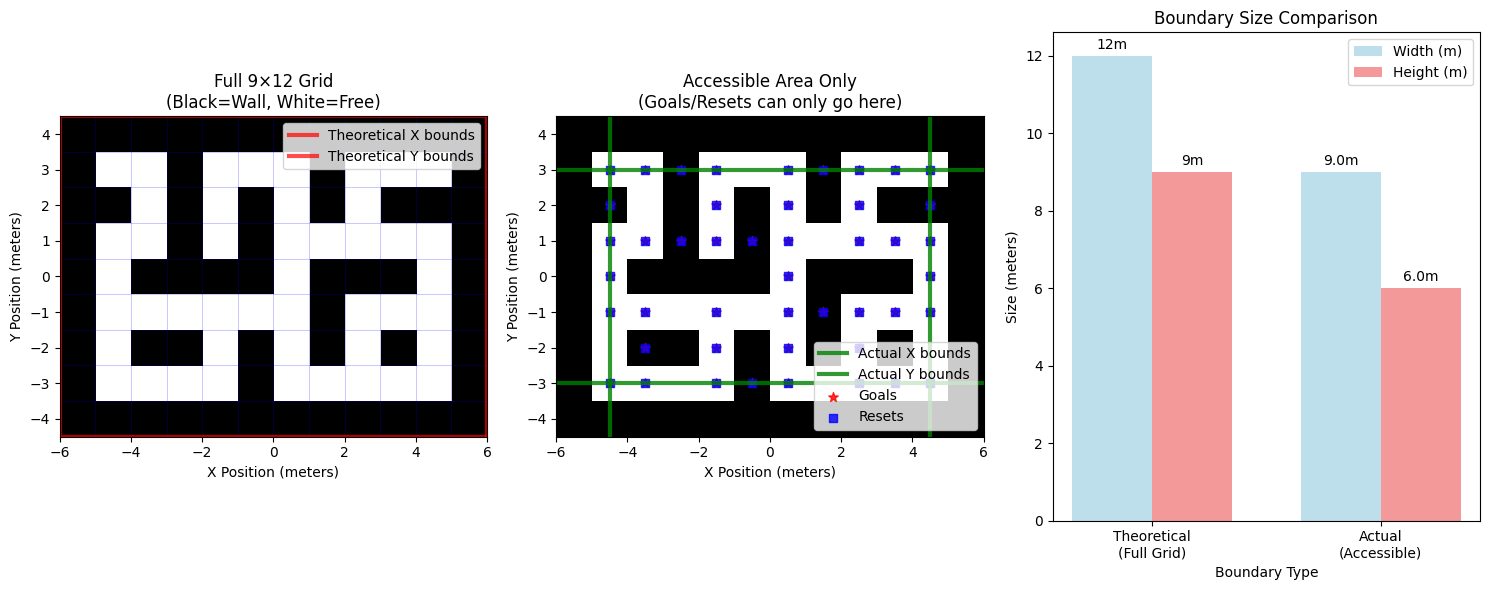


SUMMARY: WHY BOUNDARIES ≠ GRID DIMENSIONS
1. GRID SIZE: 9×12 cells = theoretical 9×12m
2. WALLS: 62 cells are walls (57.4% of grid)
3. FREE SPACE: Only 46 cells accessible (42.6% of grid)
4. ACTUAL BOUNDARIES: Only span the accessible 9.0×6.0m area
5. GOAL/RESET PLACEMENT: Only in FREE cells, not walls

So the maze is NOT a simple 9×12m rectangle!
It's a complex shape within a 9×12 grid, using only ~43% of the space.
The agent can only move in the white (free) areas, not the black (wall) areas.


In [15]:
# VISUAL COMPARISON: Grid vs Accessible Boundaries
plt.figure(figsize=(15, 6))

# Plot 1: Full grid with walls
plt.subplot(1, 3, 1)
maze_array = np.array(maze_map, dtype=float)
plt.imshow(maze_array, cmap='gray_r', origin='lower', extent=[-6, 6, -4.5, 4.5])
plt.title('Full 9×12 Grid\n(Black=Wall, White=Free)')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')

# Add grid lines
for i in range(13):  # 12 vertical lines
    plt.axvline(i-6, color='blue', alpha=0.3, linewidth=0.5)
for i in range(10):   # 9 horizontal lines  
    plt.axhline(i-4.5, color='blue', alpha=0.3, linewidth=0.5)

# Theoretical boundaries
plt.axvline(-6, color='red', linewidth=3, alpha=0.7, label='Theoretical X bounds')
plt.axvline(6, color='red', linewidth=3, alpha=0.7)
plt.axhline(-4.5, color='red', linewidth=3, alpha=0.7, label='Theoretical Y bounds')
plt.axhline(4.5, color='red', linewidth=3, alpha=0.7)
plt.legend()

# Plot 2: Only accessible areas
plt.subplot(1, 3, 2)
plt.imshow(maze_array, cmap='gray_r', origin='lower', extent=[-6, 6, -4.5, 4.5])
plt.title('Accessible Area Only\n(Goals/Resets can only go here)')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')

# Actual boundaries from free cells
plt.axvline(free_x_min, color='green', linewidth=3, alpha=0.8, label='Actual X bounds')
plt.axvline(free_x_max, color='green', linewidth=3, alpha=0.8)
plt.axhline(free_y_min, color='green', linewidth=3, alpha=0.8, label='Actual Y bounds')  
plt.axhline(free_y_max, color='green', linewidth=3, alpha=0.8)

# Show goal/reset positions
plt.scatter(goal_x, goal_y, c='red', marker='*', s=50, alpha=0.8, label='Goals')
plt.scatter(reset_x, reset_y, c='blue', marker='s', s=30, alpha=0.8, label='Resets')
plt.legend()

# Plot 3: Size comparison
plt.subplot(1, 3, 3)
categories = ['Theoretical\n(Full Grid)', 'Actual\n(Accessible)']
widths = [12, 9.0]  # theoretical vs actual width
heights = [9, 6.0]  # theoretical vs actual height

x = np.arange(len(categories))
width = 0.35

plt.bar(x - width/2, widths, width, label='Width (m)', alpha=0.8, color='lightblue')
plt.bar(x + width/2, heights, width, label='Height (m)', alpha=0.8, color='lightcoral')

plt.xlabel('Boundary Type')
plt.ylabel('Size (meters)')
plt.title('Boundary Size Comparison')
plt.xticks(x, categories)
plt.legend()

# Add value labels on bars
for i, (w, h) in enumerate(zip(widths, heights)):
    plt.text(i - width/2, w + 0.1, f'{w}m', ha='center', va='bottom')
    plt.text(i + width/2, h + 0.1, f'{h}m', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"\n" + "="*60)
print("SUMMARY: WHY BOUNDARIES ≠ GRID DIMENSIONS")
print("="*60)
print(f"1. GRID SIZE: {rows}×{cols} cells = theoretical {rows*cell_size}×{cols*cell_size}m")
print(f"2. WALLS: {len(wall_cells)} cells are walls ({100*len(wall_cells)/(rows*cols):.1f}% of grid)")
print(f"3. FREE SPACE: Only {len(free_cells)} cells accessible ({100*len(free_cells)/(rows*cols):.1f}% of grid)")
print(f"4. ACTUAL BOUNDARIES: Only span the accessible {actual_x_max-actual_x_min:.1f}×{actual_y_max-actual_y_min:.1f}m area")
print(f"5. GOAL/RESET PLACEMENT: Only in FREE cells, not walls")
print(f"")
print(f"So the maze is NOT a simple 9×12m rectangle!")
print(f"It's a complex shape within a 9×12 grid, using only ~43% of the space.")
print(f"The agent can only move in the white (free) areas, not the black (wall) areas.")

In [16]:
# COORDINATE SYSTEM CONVERSION FUNCTIONS
print("\n" + "="*60)
print("COORDINATE SYSTEM CONVERSION: World ↔ Grid")
print("="*60)

def world_to_grid(x, y, rows=9, cols=12):
    """
    Convert world coordinates (x,y) to grid indices (row, col)
    
    Args:
        x, y: World coordinates (meters) - can be float
        rows, cols: Grid dimensions
    
    Returns:
        (row, col): Grid indices - integers
        (grid_x, grid_y): Grid coordinates (same as col, row but more intuitive naming)
    """
    # World coordinates are centered at origin
    # Grid coordinates: (0,0) is bottom-left corner
    
    # Convert to grid coordinates
    grid_x = x + (cols - 1) / 2  # Shift to make (0,0) at bottom-left
    grid_y = y + (rows - 1) / 2  # Shift to make (0,0) at bottom-left
    
    # Convert to grid indices (integers)
    col = int(round(grid_x))  # Column index (0 to cols-1)
    row = int(round(grid_y))  # Row index (0 to rows-1)
    
    return row, col, grid_x, grid_y

def grid_to_world(row, col, rows=9, cols=12):
    """
    Convert grid indices (row, col) to world coordinates (x, y)
    
    Args:
        row, col: Grid indices (integers)
        rows, cols: Grid dimensions
        
    Returns:
        (x, y): World coordinates (meters) - centered at origin
    """
    # Convert grid indices to world coordinates
    x = col - (cols - 1) / 2
    y = row - (rows - 1) / 2
    
    return x, y

def get_grid_cell_boundaries(row, col, rows=9, cols=12):
    """
    Get the physical boundaries of a grid cell
    
    Args:
        row, col: Grid indices
        rows, cols: Grid dimensions
        
    Returns:
        (x_min, x_max, y_min, y_max): Cell boundaries in world coordinates
    """
    center_x, center_y = grid_to_world(row, col, rows, cols)
    
    # Each cell is 1m x 1m, centered at the grid point
    x_min = center_x - 0.5
    x_max = center_x + 0.5
    y_min = center_y - 0.5
    y_max = center_y + 0.5
    
    return x_min, x_max, y_min, y_max

def is_valid_grid_cell(row, col, rows=9, cols=12):
    """Check if grid indices are within bounds"""
    return 0 <= row < rows and 0 <= col < cols

def is_free_cell(row, col, maze_map):
    """Check if grid cell is free (not a wall)"""
    if not is_valid_grid_cell(row, col, len(maze_map), len(maze_map[0])):
        return False
    return maze_map[row][col] == 0

# Demonstrate the coordinate system
print("COORDINATE SYSTEM EXPLANATION:")
print(f"- Grid: {rows}×{cols} cells")
print(f"- World origin (0,0) is at center of grid")
print(f"- Grid indices: row ∈ [0, {rows-1}], col ∈ [0, {cols-1}]")
print(f"- World coordinates: x ∈ [{-(cols-1)/2:.1f}, {(cols-1)/2:.1f}], y ∈ [{-(rows-1)/2:.1f}, {(rows-1)/2:.1f}]")

print(f"\nCORNER CELL EXAMPLES:")
corners = [
    (0, 0, "Bottom-left"),
    (0, cols-1, "Bottom-right"), 
    (rows-1, 0, "Top-left"),
    (rows-1, cols-1, "Top-right"),
    (rows//2, cols//2, "Center")
]

for row, col, name in corners:
    world_x, world_y = grid_to_world(row, col, rows, cols)
    x_min, x_max, y_min, y_max = get_grid_cell_boundaries(row, col, rows, cols)
    is_free = is_free_cell(row, col, maze_map)
    
    print(f"  {name:12} | Grid({row:2d},{col:2d}) → World({world_x:5.1f},{world_y:4.1f}) | "
          f"Bounds[{x_min:5.1f},{x_max:4.1f}]×[{y_min:4.1f},{y_max:4.1f}] | {'Free' if is_free else 'Wall'}")

print(f"\nTEST CONVERSIONS - Random positions:")
test_positions = [
    (-2.3, 1.7),   # Some random position
    (0.0, 0.0),    # Origin
    (-4.5, 3.0),   # Goal position
    (2.8, -1.2),   # Another random position
    (-5.9, 4.2),   # Outside bounds
]

print(f"{'World Position':<15} | {'Grid Cell':<12} | {'Grid Coords':<15} | {'Cell Bounds':<25} | {'Status'}")
print("-" * 90)

for x, y in test_positions:
    row, col, grid_x, grid_y = world_to_grid(x, y, rows, cols)
    
    # Check if position is valid and get status
    if is_valid_grid_cell(row, col, rows, cols):
        is_free = is_free_cell(row, col, maze_map)
        status = "Free" if is_free else "Wall"
        x_min, x_max, y_min, y_max = get_grid_cell_boundaries(row, col, rows, cols)
        bounds_str = f"[{x_min:4.1f},{x_max:4.1f}]×[{y_min:4.1f},{y_max:4.1f}]"
    else:
        status = "Out of bounds"
        bounds_str = "N/A"
    
    print(f"({x:5.1f},{y:5.1f})     | ({row:2d},{col:2d})     | ({grid_x:5.1f},{grid_y:5.1f})     | {bounds_str:<25} | {status}")

print(f"\nVERIFICATION - Check some known goal positions:")
print(f"{'Goal Position':<15} | {'Expected Grid':<15} | {'Calculated Grid':<15} | {'Match'}")
print("-" * 70)

for i in range(min(5, len(goal_locations_array))):
    goal_pos = goal_locations_array[i]
    x, y = goal_pos[0], goal_pos[1]
    row, col, grid_x, grid_y = world_to_grid(x, y, rows, cols)
    
    # The goals are placed at cell boundaries, so they might be between cells
    # Let's see which cell they're closest to
    expected_x = round(x)
    expected_y = round(y)
    expected_row, expected_col, _, _ = world_to_grid(expected_x, expected_y, rows, cols)
    
    match = "✓" if (row == expected_row and col == expected_col) else "✗"
    
    print(f"({x:5.1f},{y:5.1f})     | ({expected_row:2d},{expected_col:2d})         | ({row:2d},{col:2d})           | {match}")


COORDINATE SYSTEM CONVERSION: World ↔ Grid
COORDINATE SYSTEM EXPLANATION:
- Grid: 9×12 cells
- World origin (0,0) is at center of grid
- Grid indices: row ∈ [0, 8], col ∈ [0, 11]
- World coordinates: x ∈ [-5.5, 5.5], y ∈ [-4.0, 4.0]

CORNER CELL EXAMPLES:
  Bottom-left  | Grid( 0, 0) → World( -5.5,-4.0) | Bounds[ -6.0,-5.0]×[-4.5,-3.5] | Wall
  Bottom-right | Grid( 0,11) → World(  5.5,-4.0) | Bounds[  5.0, 6.0]×[-4.5,-3.5] | Wall
  Top-left     | Grid( 8, 0) → World( -5.5, 4.0) | Bounds[ -6.0,-5.0]×[ 3.5, 4.5] | Wall
  Top-right    | Grid( 8,11) → World(  5.5, 4.0) | Bounds[  5.0, 6.0]×[ 3.5, 4.5] | Wall
  Center       | Grid( 4, 6) → World(  0.5, 0.0) | Bounds[  0.0, 1.0]×[-0.5, 0.5] | Free

TEST CONVERSIONS - Random positions:
World Position  | Grid Cell    | Grid Coords     | Cell Bounds               | Status
------------------------------------------------------------------------------------------
( -2.3,  1.7)     | ( 6, 3)     | (  3.2,  5.7)     | [-3.0,-2.0]×[ 1.5, 2.5]   | W

GRID LOOKUP DEMONSTRATION:

Goal cell example:
  Grid cell: (7, 1)
  Center: (-4.5, 3.0)
  Boundaries: X[-5.0, -4.0], Y[2.5, 3.5]
  Status: Free

Center cell:
  Grid cell: (4, 6)
  Center: (0.5, 0.0)
  Boundaries: X[0.0, 1.0], Y[-0.5, 0.5]
  Status: Free

Free cell:
  Grid cell: (1, 5)
  Center: (-0.5, -3.0)
  Boundaries: X[-1.0, 0.0], Y[-3.5, -2.5]
  Status: Wall

Corner cell:
  Grid cell: (0, 0)
  Center: (-5.5, -4.0)
  Boundaries: X[-6.0, -5.0], Y[-4.5, -3.5]
  Status: Wall


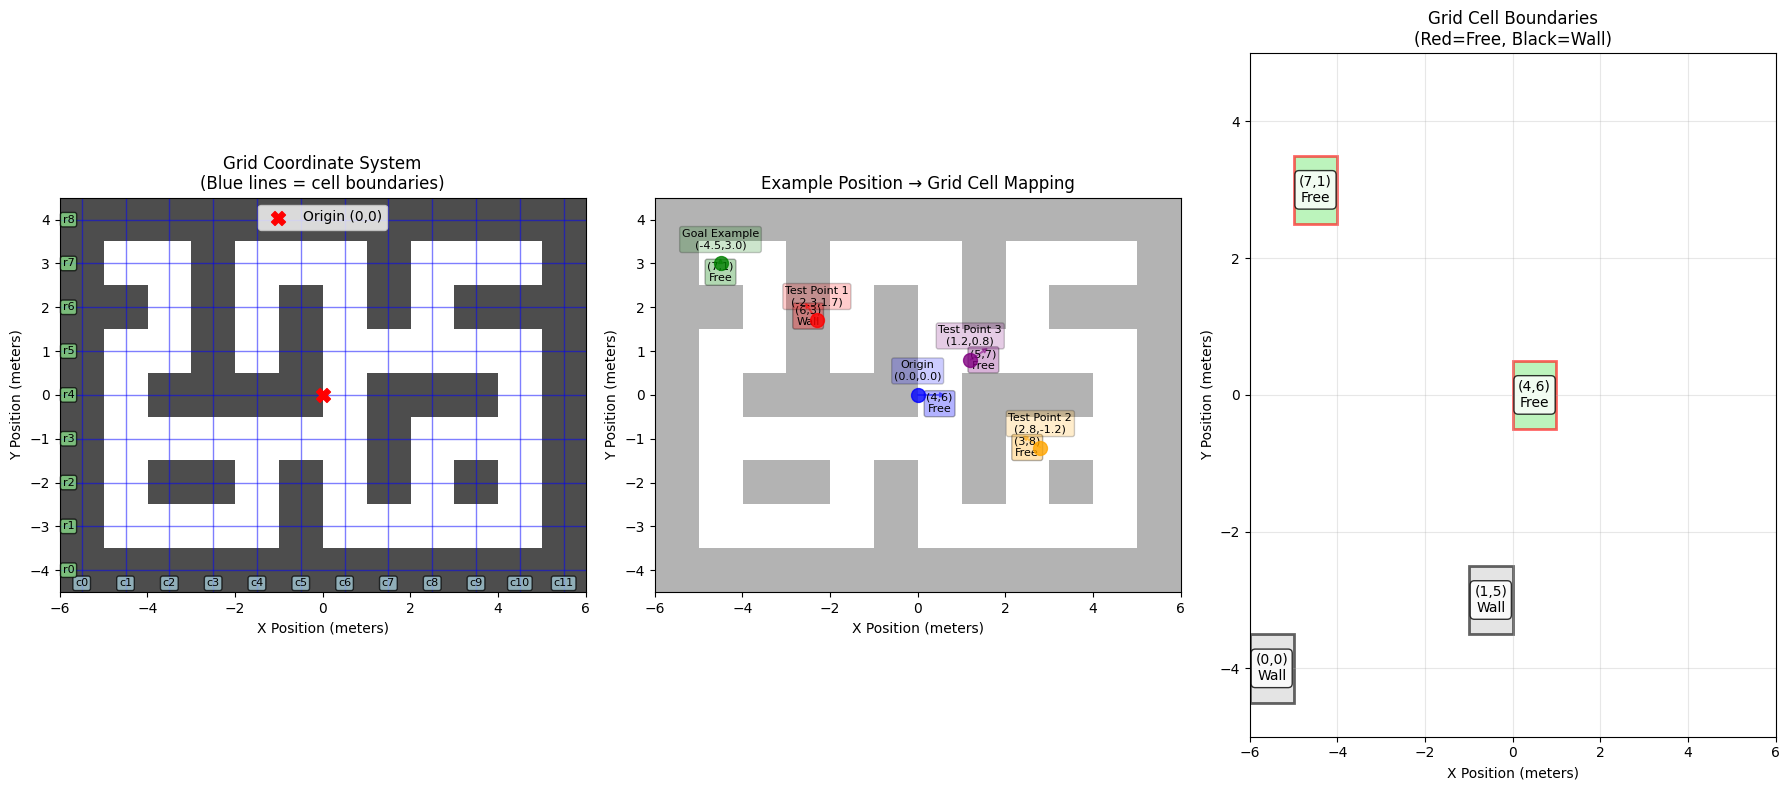


SUMMARY: COORDINATE CONVERSION
✓ Given any (x,y) position, you can find its grid cell using world_to_grid()
✓ Given any grid cell (row,col), you can find its center using grid_to_world()
✓ Each cell has boundaries of ±0.5m around its center
✓ You can check if a position is in a wall or free space
✓ The coordinate system is centered at origin (0,0)

USAGE EXAMPLES:
  row, col, _, _ = world_to_grid(-2.3, 1.7)  # Returns (6, 3)
  center_x, center_y = grid_to_world(6, 3)   # Returns (-2.5, 1.0)
  is_wall = not is_free_cell(6, 3, maze_map) # Returns True (it's a wall)


In [17]:
# VISUAL DEMONSTRATION OF COORDINATE SYSTEM
plt.figure(figsize=(18, 8))

# Plot 1: Grid with coordinates labeled
plt.subplot(1, 3, 1)
maze_array = np.array(maze_map, dtype=float)
plt.imshow(maze_array, cmap='gray_r', origin='lower', extent=[-6, 6, -4.5, 4.5], alpha=0.7)

# Add grid lines and labels
for col in range(cols):
    x_world, _ = grid_to_world(0, col, rows, cols)
    plt.axvline(x_world, color='blue', alpha=0.5, linewidth=1)
    # Label column at bottom
    plt.text(x_world, -4.3, f'c{col}', ha='center', va='center', fontsize=8, 
             bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.7))

for row in range(rows):
    _, y_world = grid_to_world(row, 0, rows, cols)
    plt.axhline(y_world, color='blue', alpha=0.5, linewidth=1)
    # Label row on left
    plt.text(-5.8, y_world, f'r{row}', ha='center', va='center', fontsize=8,
             bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgreen', alpha=0.7))

# Add origin marker
plt.scatter([0], [0], color='red', s=100, marker='X', zorder=10, label='Origin (0,0)')

plt.title('Grid Coordinate System\n(Blue lines = cell boundaries)')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.legend()

# Plot 2: Show some example positions and their grid assignments
plt.subplot(1, 3, 2)
plt.imshow(maze_array, cmap='gray_r', origin='lower', extent=[-6, 6, -4.5, 4.5], alpha=0.3)

# Test some positions
test_points = [
    (-2.3, 1.7, 'red', 'Test Point 1'),
    (0.0, 0.0, 'blue', 'Origin'),
    (-4.5, 3.0, 'green', 'Goal Example'),
    (2.8, -1.2, 'orange', 'Test Point 2'),
    (1.2, 0.8, 'purple', 'Test Point 3')
]

for x, y, color, label in test_points:
    row, col, grid_x, grid_y = world_to_grid(x, y, rows, cols)
    
    # Plot the point
    plt.scatter([x], [y], color=color, s=100, marker='o', alpha=0.8, zorder=10)
    
    # Draw arrow to its grid cell center if valid
    if is_valid_grid_cell(row, col, rows, cols):
        center_x, center_y = grid_to_world(row, col, rows, cols)
        plt.arrow(x, y, center_x-x, center_y-y, head_width=0.1, head_length=0.1, 
                 fc=color, ec=color, alpha=0.5)
        
        # Label the grid cell
        is_free = is_free_cell(row, col, maze_map)
        cell_status = "Free" if is_free else "Wall"
        plt.text(center_x, center_y-0.2, f'({row},{col})\n{cell_status}', 
                ha='center', va='center', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.3))
    
    # Label the point
    plt.text(x, y+0.3, f'{label}\n({x:.1f},{y:.1f})', ha='center', va='bottom', 
             fontsize=8, bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.2))

plt.title('Example Position → Grid Cell Mapping')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')

# Plot 3: Interactive grid cell lookup function demonstration
plt.subplot(1, 3, 3)

# Create a simple function to demonstrate grid lookup
def demonstrate_grid_lookup():
    """Demonstrate the grid lookup for various positions"""
    print("GRID LOOKUP DEMONSTRATION:")
    print("="*40)
    
    # Show boundaries of a few interesting cells
    interesting_cells = [
        (7, 1, "Goal cell example"),  # Where goal (-4.5, 3.0) maps
        (4, 6, "Center cell"),        # Center of maze
        (1, 5, "Free cell"),          # Some free cell
        (0, 0, "Corner cell"),        # Corner (wall)
    ]
    
    for row, col, description in interesting_cells:
        if is_valid_grid_cell(row, col, rows, cols):
            center_x, center_y = grid_to_world(row, col, rows, cols)
            x_min, x_max, y_min, y_max = get_grid_cell_boundaries(row, col, rows, cols)
            is_free = is_free_cell(row, col, maze_map)
            status = "Free" if is_free else "Wall"
            
            print(f"\n{description}:")
            print(f"  Grid cell: ({row}, {col})")
            print(f"  Center: ({center_x:.1f}, {center_y:.1f})")
            print(f"  Boundaries: X[{x_min:.1f}, {x_max:.1f}], Y[{y_min:.1f}, {y_max:.1f}]")
            print(f"  Status: {status}")
            
            # Plot this cell
            rect = plt.Rectangle((x_min, y_min), x_max-x_min, y_max-y_min,
                               linewidth=2, edgecolor='red' if is_free else 'black',
                               facecolor='lightgreen' if is_free else 'lightgray', 
                               alpha=0.6)
            plt.gca().add_patch(rect)
            
            # Label the cell
            plt.text(center_x, center_y, f'({row},{col})\n{status}', 
                    ha='center', va='center', fontsize=10,
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Run the demonstration
demonstrate_grid_lookup()

plt.xlim(-6, 6)
plt.ylim(-5, 5)
plt.title('Grid Cell Boundaries\n(Red=Free, Black=Wall)')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n" + "="*60)
print("SUMMARY: COORDINATE CONVERSION")
print("="*60)
print(f"✓ Given any (x,y) position, you can find its grid cell using world_to_grid()")
print(f"✓ Given any grid cell (row,col), you can find its center using grid_to_world()")
print(f"✓ Each cell has boundaries of ±0.5m around its center")
print(f"✓ You can check if a position is in a wall or free space")
print(f"✓ The coordinate system is centered at origin (0,0)")
print(f"")
print(f"USAGE EXAMPLES:")
print(f"  row, col, _, _ = world_to_grid(-2.3, 1.7)  # Returns (6, 3)")
print(f"  center_x, center_y = grid_to_world(6, 3)   # Returns (-2.5, 1.0)")
print(f"  is_wall = not is_free_cell(6, 3, maze_map) # Returns True (it's a wall)")

In [18]:
# ENVIRONMENT GRID EDGE COORDINATES (Regardless of Walls)
print("="*60)
print("FULL ENVIRONMENT GRID BOUNDARIES")
print("="*60)

print(f"Grid dimensions: {rows} × {cols} cells")
print(f"Cell size: {cell_size}m × {cell_size}m")

# Calculate the four edges of the complete grid
# The grid extends from the center of the corner cells outward by 0.5m

# Corner cells (grid indices)
bottom_left = (0, 0)
bottom_right = (0, cols-1)
top_left = (rows-1, 0)
top_right = (rows-1, cols-1)

print(f"\nCORNER CELLS (Grid indices):")
print(f"  Bottom-left:  {bottom_left}")
print(f"  Bottom-right: {bottom_right}")
print(f"  Top-left:     {top_left}")
print(f"  Top-right:    {top_right}")

# Convert to world coordinates (centers)
bl_x, bl_y = grid_to_world(bottom_left[0], bottom_left[1], rows, cols)
br_x, br_y = grid_to_world(bottom_right[0], bottom_right[1], rows, cols)
tl_x, tl_y = grid_to_world(top_left[0], top_left[1], rows, cols)
tr_x, tr_y = grid_to_world(top_right[0], top_right[1], rows, cols)

print(f"\nCORNER CELL CENTERS (World coordinates):")
print(f"  Bottom-left:  ({bl_x:5.1f}, {bl_y:4.1f})")
print(f"  Bottom-right: ({br_x:5.1f}, {br_y:4.1f})")
print(f"  Top-left:     ({tl_x:5.1f}, {tl_y:4.1f})")
print(f"  Top-right:    ({tr_x:5.1f}, {tr_y:4.1f})")

# Calculate the absolute edges (extending 0.5m beyond cell centers)
left_edge = bl_x - 0.5    # Leftmost edge
right_edge = br_x + 0.5   # Rightmost edge
bottom_edge = bl_y - 0.5  # Bottom edge
top_edge = tl_y + 0.5     # Top edge

print(f"\nTHE FOUR EDGES OF THE ENVIRONMENT:")
print(f"  Left edge   (min X): {left_edge:6.1f}m")
print(f"  Right edge  (max X): {right_edge:6.1f}m")
print(f"  Bottom edge (min Y): {bottom_edge:6.1f}m")
print(f"  Top edge    (max Y): {top_edge:6.1f}m")

print(f"\nTOTAL ENVIRONMENT SIZE:")
total_width = right_edge - left_edge
total_height = top_edge - bottom_edge
print(f"  Width:  {total_width:.1f}m ({cols} cells × {cell_size}m)")
print(f"  Height: {total_height:.1f}m ({rows} cells × {cell_size}m)")

print(f"\nBOUNDING BOX:")
print(f"  X range: [{left_edge:6.1f}, {right_edge:6.1f}]")
print(f"  Y range: [{bottom_edge:6.1f}, {top_edge:6.1f}]")

print(f"\nNOTE:")
print(f"  These are the ABSOLUTE edges of the {rows}×{cols} grid.")
print(f"  This includes both walls AND free space.")
print(f"  Any position outside these bounds is completely outside the environment.")

FULL ENVIRONMENT GRID BOUNDARIES
Grid dimensions: 9 × 12 cells
Cell size: 1m × 1m

CORNER CELLS (Grid indices):
  Bottom-left:  (0, 0)
  Bottom-right: (0, 11)
  Top-left:     (8, 0)
  Top-right:    (8, 11)

CORNER CELL CENTERS (World coordinates):
  Bottom-left:  ( -5.5, -4.0)
  Bottom-right: (  5.5, -4.0)
  Top-left:     ( -5.5,  4.0)
  Top-right:    (  5.5,  4.0)

THE FOUR EDGES OF THE ENVIRONMENT:
  Left edge   (min X):   -6.0m
  Right edge  (max X):    6.0m
  Bottom edge (min Y):   -4.5m
  Top edge    (max Y):    4.5m

TOTAL ENVIRONMENT SIZE:
  Width:  12.0m (12 cells × 1m)
  Height: 9.0m (9 cells × 1m)

BOUNDING BOX:
  X range: [  -6.0,    6.0]
  Y range: [  -4.5,    4.5]

NOTE:
  These are the ABSOLUTE edges of the 9×12 grid.
  This includes both walls AND free space.
  Any position outside these bounds is completely outside the environment.


In [19]:
# SHOW THE COORDINATE CONVERSION FUNCTIONS
print("="*60)
print("COORDINATE CONVERSION FUNCTIONS")
print("="*60)

print("Here are the functions I created earlier:\n")

# Show the world_to_grid function
print("1. world_to_grid(x, y) - Convert (x,y) position to grid cell:")
print("="*50)
print("""
def world_to_grid(x, y, rows=9, cols=12):
    \"\"\"
    Convert world coordinates (x,y) to grid indices (row, col)
    
    Args:
        x, y: World coordinates (meters) - can be float
        rows, cols: Grid dimensions
    
    Returns:
        (row, col): Grid indices - integers
        (grid_x, grid_y): Grid coordinates (same as col, row but more intuitive naming)
    \"\"\"
    # World coordinates are centered at origin
    # Grid coordinates: (0,0) is bottom-left corner
    
    # Convert to grid coordinates
    grid_x = x + (cols - 1) / 2  # Shift to make (0,0) at bottom-left
    grid_y = y + (rows - 1) / 2  # Shift to make (0,0) at bottom-left
    
    # Convert to grid indices (integers)
    col = int(round(grid_x))  # Column index (0 to cols-1)
    row = int(round(grid_y))  # Row index (0 to rows-1)
    
    return row, col, grid_x, grid_y
""")

print("\n2. grid_to_world(row, col) - Convert grid cell to (x,y) position:")
print("="*50)
print("""
def grid_to_world(row, col, rows=9, cols=12):
    \"\"\"
    Convert grid indices (row, col) to world coordinates (x, y)
    
    Args:
        row, col: Grid indices (integers)
        rows, cols: Grid dimensions
        
    Returns:
        (x, y): World coordinates (meters) - centered at origin
    \"\"\"
    # Convert grid indices to world coordinates
    x = col - (cols - 1) / 2
    y = row - (rows - 1) / 2
    
    return x, y
""")

print("\n3. get_grid_cell_boundaries(row, col) - Get cell boundaries:")
print("="*50)
print("""
def get_grid_cell_boundaries(row, col, rows=9, cols=12):
    \"\"\"
    Get the physical boundaries of a grid cell
    
    Args:
        row, col: Grid indices
        rows, cols: Grid dimensions
        
    Returns:
        (x_min, x_max, y_min, y_max): Cell boundaries in world coordinates
    \"\"\"
    center_x, center_y = grid_to_world(row, col, rows, cols)
    
    # Each cell is 1m x 1m, centered at the grid point
    x_min = center_x - 0.5
    x_max = center_x + 0.5
    y_min = center_y - 0.5
    y_max = center_y + 0.5
    
    return x_min, x_max, y_min, y_max
""")

print("\n4. is_free_cell(row, col, maze_map) - Check if cell is free:")
print("="*50)
print("""
def is_free_cell(row, col, maze_map):
    \"\"\"Check if grid cell is free (not a wall)\"\"\"
    if not (0 <= row < len(maze_map) and 0 <= col < len(maze_map[0])):
        return False
    return maze_map[row][col] == 0
""")

print("\n" + "="*60)
print("TESTING THE FUNCTIONS")
print("="*60)

# Test the functions with some examples
test_examples = [
    (-2.3, 1.7, "Random position"),
    (0.0, 0.0, "Origin"),
    (-4.5, 3.0, "Goal position"),
    (2.8, -1.2, "Another position")
]

print(f"{'Position':<15} | {'Grid Cell':<12} | {'Grid Coords':<15} | {'Cell Center':<15} | {'Status'}")
print("-" * 85)

for x, y, description in test_examples:
    # Convert world to grid
    row, col, grid_x, grid_y = world_to_grid(x, y, rows, cols)
    
    # Convert back to world (should give cell center)
    center_x, center_y = grid_to_world(row, col, rows, cols)
    
    # Check if free or wall
    if 0 <= row < rows and 0 <= col < cols:
        is_free = is_free_cell(row, col, maze_map)
        status = "Free" if is_free else "Wall"
    else:
        status = "Out of bounds"
    
    print(f"({x:5.1f},{y:5.1f})     | ({row:2d},{col:2d})     | ({grid_x:5.1f},{grid_y:5.1f})     | ({center_x:5.1f},{center_y:5.1f})     | {status}")

print(f"\nThese functions are already defined and available in your notebook!")

COORDINATE CONVERSION FUNCTIONS
Here are the functions I created earlier:

1. world_to_grid(x, y) - Convert (x,y) position to grid cell:

def world_to_grid(x, y, rows=9, cols=12):
    """
    Convert world coordinates (x,y) to grid indices (row, col)

    Args:
        x, y: World coordinates (meters) - can be float
        rows, cols: Grid dimensions

    Returns:
        (row, col): Grid indices - integers
        (grid_x, grid_y): Grid coordinates (same as col, row but more intuitive naming)
    """
    # World coordinates are centered at origin
    # Grid coordinates: (0,0) is bottom-left corner

    # Convert to grid coordinates
    grid_x = x + (cols - 1) / 2  # Shift to make (0,0) at bottom-left
    grid_y = y + (rows - 1) / 2  # Shift to make (0,0) at bottom-left

    # Convert to grid indices (integers)
    col = int(round(grid_x))  # Column index (0 to cols-1)
    row = int(round(grid_y))  # Row index (0 to rows-1)

    return row, col, grid_x, grid_y


2. grid_to_world(row, 